#Group Information:
Group Name: AutoBots
Members: Grandi Simone, Lazzari Luca, Nipoti Alessandro,  Alessandro Nipoti Sharma Vivekkumar, Shauryaaditya Singh

#Setup Enviroment (Entertaiment, Science, Philosphy/History, News)



##Imports and drive mounting

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import sys
import os

# Define the path to the directory containing your package
package_parent_dir = '/content/drive/MyDrive/Colab Notebooks/NLP_assignment'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/Colab Notebooks/NLP_assignment']


##PoliMillionarie API Connection

In [ ]:
import sys
import os

# Define the path to the directory containing your package (ensure it's accessible)
package_parent_dir = '/content/gdrive/MyDrive/Colab Notebooks/NLP_assignment_api_client'

# Append to sys.path if it is not already present, ensuring the module can be found
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

from millionaire_client import MillionaireClient, AuthenticationError
from google.colab import userdata
API_URL = "http://131.175.15.22:51111/"
username = "liuk" #we used the authentication from one of the group members
password = userdata.get('poli-millionaire')

# We can instantiate a MillionaireClient object and call the login method,
# which takes as parameters username and password.
game_client = MillionaireClient(API_URL)
try:
    user = game_client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

ModuleNotFoundError: No module named 'millionaire_client'

## Required Libraries installation

In [ ]:
!pip install transformers accelerate bitsandbytes sympy sentence-transformers PyPDF2 duckduckgo-search beautifulsoup4
!pip install -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


##Download of the model from Huggin Face

In [ ]:
from huggingface_hub import login
from google.colab import userdata
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

login(token=userdata.get('HF_TOKEN'))

model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Configure 4-bit quantization to fit the model in the free Colab GPU
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Loading model locally...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto" # Automatically places the model on the GPU
)
print("Model loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
# from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
# import torch
# import tempfile

# offload_dir = tempfile.mkdtemp()

# model_id = "Qwen/Qwen3-1.7B" # Changed model to 1.7B version

# tokenizer = AutoTokenizer.from_pretrained(
#     model_id,
#     trust_remote_code=True
# )

# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     device_map="auto",
#     torch_dtype="auto",
#     offload_folder=offload_dir,
#     offload_buffers=True,
#     trust_remote_code=True
# )

# generator = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer
# )

# output = generator(
#     "Explain quantum computing simply.",
#     max_new_tokens=200
# )

# print(output[0]["generated_text"])

##Download Embedding model for RAGs

In [ ]:
from sentence_transformers import SentenceTransformer
print("Loading embedding model for RAG...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading embedding model for RAG...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#Setup Enviroment (Math)



##Imports and drive mounting

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
import os

# Define the path to the directory containing your package
package_parent_dir = '/content/drive/MyDrive/Colab Notebooks/NLP_assignment'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/Colab Notebooks/NLP_assignment']


In [ ]:
import os

print(f"Contents of {package_parent_dir}:")
for item in os.listdir(package_parent_dir):
    print(f"- {item}")

millionaire_client_path = os.path.join(package_parent_dir, 'millionaire_client')
if os.path.exists(millionaire_client_path) and os.path.isdir(millionaire_client_path):
    print(f"\nContents of {millionaire_client_path}:")
    for item in os.listdir(millionaire_client_path):
        print(f"- {item}")
    if '__init__.py' in os.listdir(millionaire_client_path):
        print("\nFound '__init__.py' in 'millionaire_client' folder. This is good!")
    else:
        print("\nWarning: '__init__.py' not found in 'millionaire_client' folder. This might be the cause of the error.")
else:
    print("\nError: 'millionaire_client' folder not found inside the specified 'package_parent_dir'.")

Contents of /content/drive/MyDrive/Colab Notebooks/NLP_assignment:
- millionaire_client
- llama_answers.txt
- PoliMillionaire.ipynb
- PoliMillionaire_llama.ipynb
- FirstExperiments.ipynb
- PoliMillionaire_ablation.ipynb
- ScienceWithHints.ipynb
- Books
- Database
- Copia di Main_PoliMillionaire (1).ipynb
- Copia di Main_PoliMillionaire.ipynb
- Main_PoliMillionaire_newTopics.ipynb
- Main_PoliMillionaire_speech.ipynb
- PoliSpeech.ipynb
- Copia di Main_PoliMillionaire (local rag).ipynb
- News_RAG.ipynb
- Main_PoliMillionaire(News_and_Enteritaiment).ipynb
- Math_DeepSeek_Expiriment.ipynb
- Main_PoliMillionaire.ipynb
- 0_Main_PoliMillionaire_FINAL (copy).ipynb
- 0_Copy_with_old_math_agent.ipynb
- 00_TRY_03.ipynb
- 0_(OLD)_Main_PoliMillionaire_FINAL.ipynb
- 0_(UPDATED   NEW)_Main_PoliMillionaire_FINAL.ipynb
- 0_Main_PoliMillionaire_FINAL (nipo).ipynb
- Copia di 0_FINAL_Notebook.ipynb
- (SIMO)_Expiriments.ipynb
- 0_FINAL_Notebook.ipynb
- (LUCA)_Expiriments.ipynb
- 0_Main_PoliMillionaire_FINAL

##PoliMillionarie API Connection

In [ ]:
import sys
import os

# Define the path to the directory containing your package (ensure it's accessible)
package_parent_dir = '/content/gdrive/MyDrive/Colab Notebooks/NLP_assignment_api_client'

# Append to sys.path if it is not already present, ensuring the module can be found
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

from millionaire_client import MillionaireClient, AuthenticationError
from google.colab import userdata
API_URL = "http://131.175.15.22:51111/"
username = "liuk" #we used the authentication from one of the group members
password = userdata.get('poli-millionaire')

# We can instantiate a MillionaireClient object and call the login method,
# which takes as parameters username and password.
game_client = MillionaireClient(API_URL)
try:
    user = game_client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")


Welcome, liuk! (Role: student)


##Required Libraries Installation

In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 63.8 MB/s eta 0:00:00


In [ ]:
!uv pip install --system "transformers<5.0.0"
!uv pip install --system vllm==0.19.0
!uv pip install --system langchain langchain-openai langchain_experimental

Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 400ms
Prepared 2 packages in 540ms
Uninstalled 2 packages in 385ms
Installed 2 packages in 44ms
 - huggingface-hub==1.16.1
 + huggingface-hub==0.36.2
 - transformers==5.0.0
 + transformers==4.57.6
Using Python 3.12.13 environment at: /usr
Resolved 175 packages in 1.76s
Prepared 60 packages in 1m 27s
Uninstalled 12 packages in 820ms
Installed 60 packages in 690ms
 + anthropic==0.105.2
 + apache-tvm-ffi==0.1.11
 + astor==0.8.1
 + blake3==1.0.8
 + cbor2==6.1.2
 + compressed-tensors==0.14.0.1
 - cuda-bindings==12.9.6
 + cuda-bindings==12.9.4
 - cuda-python==12.9.6
 + cuda-python==12.9.4
 + depyf==0.20.0
 + detect-installer==0.1.0
 + diskcache==5.6.3
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi-cli==0.0.24
 + fastapi-cloud-cli==0.19.0
 + fastar==0.11.0
 + flashinfer-cubin==0.6.6
 + flashinfer-python==0.6.6
 + gguf==0.19.0
 + ijson==3.5.0
 + interegular==0.3.3
 + jmespath==1.1.0
 - lark==1.3.1
 + lark==1.2.2
 + llg

####Model download and vLLM server start

In [ ]:
import subprocess
import time
import urllib.request
import os
import sys
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
os.environ["HF_TOKEN"] = hf_token
os.environ["VLLM_USE_V1"] = "0"

os.system("pkill -9 -f vllm")
os.system("fuser -k 8000/tcp")
time.sleep(5)

cmd_vllm = INIT_VLLM_CMD

process = subprocess.Popen(cmd_vllm, shell=True)

server_up = False
tries = 0
read_lines = 0

while not server_up and tries < 300:
    try:
        if os.path.exists("vllm.log"):
            with open("vllm.log", "r") as f:
                lines = f.readlines()
                for line in lines[read_lines:]:
                    sys.stdout.write(f"[vLLM Server]: {line}")
                    sys.stdout.flush()
                read_lines = len(lines)

        urllib.request.urlopen("http://localhost:8000/v1/models")
        server_up = True
        print("\n" + "-"*50)
        print("SERVER READY!")
        print("="*50)

    except Exception:
        time.sleep(3)
        tries += 1

if not server_up:
  print("\n" + "-"*50)
  print("""\nError: 15 minutes have already passed. The server did not start in time.
  \n Please check the code and the logs of vLLM (with command: !tail -n 30 vllm.log) to see if there are problems.""")
  print("\n" + "-"*50)




[vLLM Server]: 2026-06-02 19:40:00.213098: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
[vLLM Server]: To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299] 
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299]        █     █     █▄   ▄█
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.19.0
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299]   █▄█▀ █     █     █     █  model   Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:26 [utils.py:299] 
[vLLM Server]: (APIServer pid=6293) INFO 06-02 19:40:2

####OpenAI Server setup

In [ ]:
from openai import OpenAI
math_client = OpenAI(
    api_key="EMPTY",
    base_url="http://localhost:8000/v1",
)


#Main functions

##Models Config Dataclasses

###LLama Config

In [ ]:
from dataclasses import dataclass
from typing import Any

@dataclass
class LlamaConfig:
  sys_prompt: str
  max_tokens: int
  is_cot: bool
  is_rag: bool
  is_agent: bool


###Math Agent Config

In [ ]:
from dataclasses import dataclass
from typing import Any

@dataclass
class MathAgentConfig:
  system_prompt: str
  max_agent_turns: int
  max_tokens: int
  temperature: float
  is_cot: bool


##Prompt Builder
#####This module generates the prompt using a base system prompt, and few-shot and RAG if present

In [ ]:
def build_prompt(question_text, options, system_prompt, examples, context):
    options_text = "\n".join([f"[{opt.id}] {opt.text}" for opt in options])

    # Adds the context at the beginning
    full_user_content = f"Context:\n{context}\n\nQuestion: {question_text}\n\nOptions:\n{options_text}" if context else f"Question: {question_text}\n\nOptions:\n{options_text}"

    # Adds the system prompt
    messages = [{"role": "system", "content": system_prompt}]

    # Adds few shot examples if present
    if examples:
        for ex in examples:
            messages.append({"role": "user",      "content": ex["user"]})
            messages.append({"role": "assistant", "content": ex["assistant"]})

    # adds the question
    messages.append({"role": "user", "content": full_user_content})

    return messages

##Inference module
#####This module manages tokenization and GPU generation

In [ ]:
import torch
def run_llm_inference(messages, max_tokens, temperature=0.1):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    #Generates the response
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    # output contains also the input so we skip the input length to decode only the aswear
    input_length = inputs.input_ids.shape[-1]
    return tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()

##Regex Parser
#####This module extracts the ID of the answear

In [ ]:
import re
def parse_answer_id(response_text, is_cot):
    # Dynamic Extraction depending on the utilization of CoT
    if is_cot:
        # If we use CoT, it must follow the FINAL_ANSWER format
        print(f"\n[Model Thought Process]:\n{response_text}\n")
        match = re.search(r'FINAL_ANSWER:\s*([0-3])', response_text)
        if match:
            return int(match.group(1))

        match_letter = re.search(r'(?:FINAL ANSWER|correct option is|answer is)[\s:]*(?:\[)?([A-D])', response_text, re.IGNORECASE)
        if match_letter:
          lettera = match_letter.group(1).upper()
          return {"A": 0, "B": 1, "C": 2, "D": 3}.get(lettera, 0)

        print("  [Parsing Warning] CoT format failed. Executing fallback.")
        # scan backwards — last digit is more likely to be the conclusion
        last_digit = re.findall(r'\b([0-3])\b', response_text)
        return int(last_digit[-1]) if last_digit else 0
    else:
        # If we don't use CoT, just grab the first valid option number it outputs
        match = re.search(r'\b([0-3])\b', response_text)
        if match:
            return int(match.group())
        print(f"  [Parsing Warning] Warning: Could not parse a number from Llama's response: '{response_text}'. Defaulting to 0.")
        return 0

##Main Orchestrator
#####This module is the universal orchestrator that orchestrates the activation of the Prompt Builder, the Inference Module and the Extraction of the ID

In [ ]:

def get_model_answer(question_text, options, system_prompt, max_tokens, is_cot, examples, context=""):
    # Activates the Prompt Builder
    messages = build_prompt(question_text, options, system_prompt, examples, context)

    # Activates Inference Module
    raw_response = run_llm_inference(messages, max_tokens)

    # Activates the Regex Parser to extract the ID
    return parse_answer_id(raw_response, is_cot)

##Master GameLoop
#####This function does three things:
#####1. Activates the router and sends the question to it
#####2. Attempts to send the answear to the server
#####3. Prints the results of the game

In [ ]:
import time

def play_game(game, mode, comp_id, examples, llama_config: LlamaConfig, math_agent_config: MathAgentConfig):
    game_times = []
    while game.in_progress:
        if mode == "text":
            question = game.current_question
        elif mode == "speech":
            question = question_audio(game)
        if not question:
            print("No question available. Game may have ended.")
            break

        print(f"\n--- Level {game.current_level} (Categoria: {comp_id}) ---")
        print(f"Q: {question.text}\n")
        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        # Agent routing
        print("\n[System] Routing the question to the specialized agent...")
        start_time = time.time()

        # Router activation
        answer_id, reasoning = router(question.text, question.options, comp_id, examples, llama_config, math_agent_config)


        generation_time = time.time() - start_time
        print(f" [System] Agent chose option: [{answer_id}] (Time: {generation_time:.2f}s)\n")
        print(f" [System] Reasoning: [{reasoning}]\n")

        # Submit answer
        MAX_RETRIES = 3
        result = None

        for attempt in range(MAX_RETRIES):
            try:
                # Attempt to send the answer to the server
                result = game.answer(answer_id)
                break

            except Exception as e:
                print(f"\nSERVER CONNECTION LOST: {e}")
                if attempt < MAX_RETRIES - 1:
                    print(f"Reconnecting and retrying... (Attempt {attempt + 2}/{MAX_RETRIES})")
                    time.sleep(2)
                else:
                    print("Server unresponsive. Forfeiting.")

        # If the server crashed 3 times in a row, we break the game loop
        if result is None: break

        #time.sleep(1.5) # To not overload server api

        if result.correct:
            print(" CORRECT!")
            if result.game_over:
                print(f"\n CONGRATULATIONS! Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f" Earned so far: ${result.earned_amount:,.2f}")
        else:
            print(" WRONG ANSWER or TIMEOUT! Game Over!")
            print(f" Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")
    return game.current_level, game.earned_amount

##Router (Question Dispatcher)
*   This module sends the question it receives from Master GameLoop to the specialized module that is able to address the question more precisaly based on the category

*   If a specialized module for the question category does not exist or if both *is_rag, is_agent* are set to *False*, the module will just redirect the question to a Main Orchestrator with a call to the "standard" get_model_answer() function. That function doesn't use Rags or Agent.

*   If an Agent or a RAG module is activated. After performing the work the RAg module and the Agent module send the question and the context added to the "standard" get_model_answer() offered by the Main Orchestrator.

*   So at the end we can say that everything passes through get_model_answer() of the Main Orchestrator module.


*   There are 4 specialist:


    1.   GENERAL WEB RAGs for News and Entertainment
    2.   Wikipedia WEB RAGs for History and Philosophy
    3.   Local RAG for Science
    4.   ReAct Agent with Verifier Pattern and Calculator tool for Math






In [ ]:
from dataclasses import asdict
def router(question_text, options, comp_id, examples, llama_config: LlamaConfig, math_agent_config: MathAgentConfig):
    # Specialist 1: GENERAL WEB RAGs (News: 5, Entertainment: 0)
    if comp_id in [0, 5] and llama_config.is_rag:
        print("  -> [Router] Assigned to specialist: GENERAL WEB RAG MODULE")
        return get_llama_answer_Web_RAG(question_text, options, comp_id, llama_config.sys_prompt, llama_config.max_tokens, llama_config.is_cot, examples), None

    # Specialist 2: Wikipedia RAGs (History: 1, Philosophy: 4)
    elif comp_id in [1, 4] and llama_config.is_rag:
        print("  -> [Router] Assigned to specialist: WIKIPEDIA WEB RAG MODULE")
        return get_local_rag_answer(question_text, options, llama_config.sys_prompt, llama_config.max_tokens, llama_config.is_cot, examples, 1, dense_search_rerank, 'wiki'), None

    # Specialist 3: Local RAG (Science: 2)
    elif comp_id == 2 and llama_config.is_rag:
        print("  -> [Router] Assigned to specialist: LOCAL SCIENCE RAG MODULE")
        return get_local_rag_answer(question_text, options, llama_config.sys_prompt, llama_config.max_tokens, llama_config.is_cot, examples, 1, dense_search_rerank, 'science'), None

    # Specialist 4: Calculator (Math: 3)
    elif comp_id == 3 and llama_config.is_agent:
        print("  -> [Router] Assigned to specialist: MATH CALCULATOR TOOL")
        return get_math_agent_response(question_text, options, examples, **asdict(math_agent_config))

    #Standard module
    else:
        print("  -> [Router] Assigned to: STANDARD MODULE")

        # Calls the standard function that doesn't use Rags and Agents
        answer_id = get_model_answer(
            question_text=question_text,
            options=options,
            system_prompt=llama_config.sys_prompt,
            max_tokens=llama_config.max_tokens,
            is_cot=llama_config.is_cot,
            examples=examples
        )
        return answer_id, None

##Enviroment Cleaner

In [ ]:
import gc
import torch
def cleanEnviroment():
  print("\n\n========================================================================")
  print("                    START CLEANING OF ENVIROMENT                            ")
  print("========================================================================")
  if 'model' in globals():
    del globals()['model']

  if 'tokenizer' in globals():
    del globals()['tokenizer']

  if 'embedding_model' in globals():
      del globals()['embedding_model']

  gc.collect()
  torch.cuda.empty_cache()
  print("\n\n========================================================================")
  print("             FINISHED CLEANING OF ENVIROMENT, LAUNCHING vLLM                ")
  print("========================================================================")

## Benchmark

In [ ]:
import statistics
import time

GAME_TIMES = []

COMPETITIONS = {
    #0: "Entertainment",
    #1: "Ancient History and Politics",
    #2: "Science and Nature",
    #4: "Philosophy and Psychology",
    #5: "News",
    3: "Math"
}



def run_benchmark(game_client, mode, num_games, use_few_shot, examples_db, llama_config: LlamaConfig | None, math_agent_config: MathAgentConfig | None):
    print(f"\n==========================================")
    print(f" STARTING BENCHMARK ({num_games} GAMES per topic)")
    print(f"==========================================\n")

    all_results = {}

    for comp_id, comp_name in COMPETITIONS.items():
        print(f"\n --- TESTING CATEGORY: {comp_name} (ID: {comp_id}) --- ")

        levels_reached = []
        total_earnings = []

        # dynamic pick the example based on the settings use_few_shot, comp_id and is_cot
        if not use_few_shot:
            current_examples = None
        elif llama_config.is_cot:
            current_examples = examples_db[comp_id]["cot"]
        else:
            current_examples = examples_db[comp_id]["standard"]

        for i in range(num_games):
            print(f" --- Starting Game {i + 1}/{num_games} ---")

            # Instantiate game session
            if mode == "text":
                game = game_client.game.start(competition_id=comp_id)
            elif mode == "speech":
                game = game_client.game.start(competition_id=comp_id, mode=mode)
            else:
              print(f"\nInvalid mode. Must be 'text' or 'speech'.")

            time_start = time.time()
            level, earnings = play_game(
                  game=game,
                  mode=mode,
                  comp_id=comp_id,
                  examples=current_examples,
                  llama_config=llama_config,
                  math_agent_config=math_agent_config,
              )

            time_spent = time.time() - time_start
            GAME_TIMES.append(time_spent)

            levels_reached.append(level)
            total_earnings.append(earnings)

            time.sleep(2) #delay to not overload the api

        # Calculate the medians for this category
        median_level = statistics.median(levels_reached)
        median_earnings = statistics.median(total_earnings)

        all_results[comp_name] = {
            "median_level": median_level,
            "median_earnings": median_earnings,
            "all_levels": levels_reached,
            "all_earnings": total_earnings
        }

    print("\n\n==========================================")
    print("             FINAL RESULTS                ")
    print("==========================================")
    for name, stats in all_results.items():
        print(f"{name}:")
        print(f"    Median Level:    {stats['median_level']}")
        print(f"    Median Earnings: ${stats['median_earnings']:,.2f}")

    return all_results

##Few-shot examples


In [ ]:
EXAMPLES_DB = {
0: {  # Entertainment
        "standard": [
            {
                "user": "Question: In The Matrix, what color is the pill Neo takes to learn the truth?\n\nOptions:\n[0] Blue\n[1] White\n[2] Red\n[3] Green",
                "assistant": "2"
            },
            {
                "user": "Question: Which director directed the epic film 'The Godfather'?\n\nOptions:\n[0] Martin Scorsese\n[1] Steven Spielberg\n[2] Francis Ford Coppola\n[3] Stanley Kubrick",
                "assistant": "2"
            }
        ],
        "cot": [
            {
                "user": "Question: In The Matrix, what color is the pill Neo takes to learn the truth?\n\nOptions:\n[0] Blue\n[1] White\n[2] Red\n[3] Green",
                "assistant": "The red pill vs. blue pill is the central choice of the film — Neo takes the red one to wake up from the simulation. Option [2] matches.\nFINAL_ANSWER: 2"
            },
            {
                "user": "Question: Which director directed the epic film 'The Godfather'?\n\nOptions:\n[0] Martin Scorsese\n[1] Steven Spielberg\n[2] Francis Ford Coppola\n[3] Stanley Kubrick",
                "assistant": "The Godfather is a 1972 American crime film directed by Francis Ford Coppola, who co-wrote the screenplay with Mario Puzo. Option [2] matches.\nFINAL_ANSWER: 2"
            }
        ]
    },

    1: {  # Ancient History and Politics
        "standard": [
            {
                "user": "Question: Which ancient wonder was located in Alexandria, Egypt?\n\nOptions:\n[0] The Colossus of Rhodes\n[1] The Lighthouse of Alexandria\n[2] The Hanging Gardens\n[3] The Temple of Artemis",
                "assistant": "1"
            },
            {
                "user": "Question: What form of government did ancient Athens pioneer?\n\nOptions:\n[0] Oligarchy\n[1] Monarchy\n[2] Democracy\n[3] Theocracy",
                "assistant": "2"
            }
        ],
        "cot": [
            {
                "user": "Question: Which ancient wonder was located in Alexandria, Egypt?\n\nOptions:\n[0] The Colossus of Rhodes\n[1] The Lighthouse of Alexandria\n[2] The Hanging Gardens\n[3] The Temple of Artemis",
                "assistant": "The city name is the giveaway — the Lighthouse of Alexandria was built on the island of Pharos near Alexandria. Option [1] matches.\nFINAL_ANSWER: 1"
            },
            {
                "user": "Question: What form of government did ancient Athens pioneer?\n\nOptions:\n[0] Oligarchy\n[1] Monarchy\n[2] Democracy\n[3] Theocracy",
                "assistant": "Athens is credited as the birthplace of democracy under Cleisthenes, giving citizens a direct vote. Option [2] matches.\nFINAL_ANSWER: 2"
            }
        ]
    },

    2: {  # Science and Nature
        "standard": [
            {
                "user": "Question: What is the chemical symbol for gold?\n\nOptions:\n[0] Go\n[1] Gd\n[2] Au\n[3] Ag",
                "assistant": "2"
            },
            {
                "user": "Question: How many bones are in the adult human body?\n\nOptions:\n[0] 206\n[1] 215\n[2] 189\n[3] 230",
                "assistant": "0"
            }
        ],
        "cot": [
            {
                "user": "Question: What is the chemical symbol for gold?\n\nOptions:\n[0] Go\n[1] Gd\n[2] Au\n[3] Ag",
                "assistant": "Gold's symbol Au comes from the Latin 'aurum'. Option [2] matches.\nFINAL_ANSWER: 2"
            },
            {
                "user": "Question: How many bones are in the adult human body?\n\nOptions:\n[0] 206\n[1] 215\n[2] 189\n[3] 230",
                "assistant": "The adult human skeleton has 206 bones, a fact from basic anatomy. That text appears under option [0].\nFINAL_ANSWER: 0"
            }
        ]
    },

    3: {  # Maths
        "standard": [
            {
                "user": "Question: Two variables, x and y, seem to be exponentially related. The natural logarithm of each y value is taken and the least-squares regression line of ln(y) on x is determined to be ln(y) = 3.2 + 0.42x. What is the predicted value of y when x = 7?\n\nOptions:\nA) 6.14 B) 521.35 C) 1380384.27 D) 464.05",
                "assistant": "Let's find ln(y) at x = 7: ln(y) = 3.2 + 0.42 * 7 = 3.2 + 2.94 = 6.14. Therefore, y = e^6.14. Since e ≈ 2.718, e^6 is approximately 403. A slightly higher value matches option D perfectly.\nFINAL ANSWER: D"
            },
            {
                "user": "Question: In a normally distributed population, the mean is 125.4 and the standard deviation is 15.2. What is the approximate z-score for a value of 148.8?\n\nOptions:\nA) 1.54 B) 1.96 C) 0.85 D) 2.12",
                "assistant": "The formula is z = (148.8 - 125.4) / 15.2. I will calculate this. The numerator is 23.4. 23.4 / 15.2 is approximately 1.539. This matches option A (1.54).\nFINAL ANSWER: A"
            }
        ],
        "cot": [
            {
                "user": "Question: Two variables, x and y, seem to be exponentially related. The natural logarithm of each y value is taken and the least-squares regression line of ln(y) on x is determined to be ln(y) = 3.2 + 0.42x. What is the predicted value of y when x = 7?\n\nOptions:\nA) 6.14 B) 521.35 C) 1380384.27 D) 464.05",
                "assistant": "Let's find ln(y) at x = 7: ln(y) = 3.2 + 0.42 * 7 = 3.2 + 2.94 = 6.14. Therefore, y = e^6.14. Since e ≈ 2.718, e^6 is approximately 403. A slightly higher value matches option D perfectly.\nFINAL ANSWER: D"
            },
            {
                "user": "Question: In a normally distributed population, the mean is 125.4 and the standard deviation is 15.2. What is the approximate z-score for a value of 148.8?\n\nOptions:\nA) 1.54 B) 1.96 C) 0.85 D) 2.12",
                "assistant": "The formula is z = (148.8 - 125.4) / 15.2. I will calculate this. The numerator is 23.4. 23.4 / 15.2 is approximately 1.539. This matches option A (1.54).\nFINAL ANSWER: A"
            }
        ]
    },
  5: {  # News
        "standard": [
            {
                "user": "Question: 2024-03-26: What major infrastructure collapsed in Baltimore after being struck by a container ship?\n\nOptions:\n[0] Golden Gate Bridge\n[1] Francis Scott Key Bridge\n[2] Brooklyn Bridge\n[3] Sunshine Skyway Bridge",
                "assistant": "1"
            },
            {
                "user": "Question: 2023-05-06: Who was officially crowned as the monarch of the United Kingdom on this date?\n\nOptions:\n[0] Queen Elizabeth II\n[1] King Charles III\n[2] Prince William\n[3] Prince Harry",
                "assistant": "1"
            }
        ],
        "cot": [
            {
                "user": "Question: 2024-03-26: What major infrastructure collapsed in Baltimore after being struck by a container ship?\n\nOptions:\n[0] Golden Gate Bridge\n[1] Francis Scott Key Bridge\n[2] Brooklyn Bridge\n[3] Sunshine Skyway Bridge",
                "assistant": "On March 26, 2024, the Francis Scott Key Bridge in Baltimore collapsed after the cargo ship Dali lost power and struck one of its support columns. Option [1] matches.\nFINAL_ANSWER: 1"
            },
            {
                "user": "Question: 2023-05-06: Who was officially crowned as the monarch of the United Kingdom on this date?\n\nOptions:\n[0] Queen Elizabeth II\n[1] King Charles III\n[2] Prince William\n[3] Prince Harry",
                "assistant": "The coronation of Charles III and his wife, Camilla, as king and queen of the United Kingdom took place on May 6, 2023. Option [1] matches.\nFINAL_ANSWER: 1"
            }
        ]
    }
}

In [ ]:
EXAMPLES_DB1 = {
    0: {  # Entertainment
        "standard": [
            {
                "user": "Question: In The Matrix, what color is the pill Neo takes to learn the truth?\n\nOptions:\n[0] Blue\n[1] White\n[2] Red\n[3] Green",
                "assistant": "2"
            }
        ],
        "cot": [
            {
                "user": "Question: In The Matrix, what color is the pill Neo takes to learn the truth?\n\nOptions:\n[0] Blue\n[1] White\n[2] Red\n[3] Green",
                "assistant": "The red pill vs. blue pill is the central choice of the film — Neo takes the red one to wake up from the simulation. Option [2] matches.\nFINAL_ANSWER: 2"
            }
        ]
    },
    1: {  # Ancient History and Politics
        "standard": [
            {
                "user": "Question: Which ancient wonder was located in Alexandria, Egypt?\n\nOptions:\n[0] The Colossus of Rhodes\n[1] The Lighthouse of Alexandria\n[2] The Hanging Gardens\n[3] The Temple of Artemis",
                "assistant": "1"
            }
        ],
        "cot": [
            {
                "user": "Question: Which ancient wonder was located in Alexandria, Egypt?\n\nOptions:\n[0] The Colossus of Rhodes\n[1] The Lighthouse of Alexandria\n[2] The Hanging Gardens\n[3] The Temple of Artemis",
                "assistant": "The city name is the giveaway — the Lighthouse of Alexandria was built on the island of Pharos near Alexandria. Option [1] matches.\nFINAL_ANSWER: 1"
            }
        ]
    },
    2: {  # Science and Nature
        "standard": [
            {
                "user": "Question: What is the chemical symbol for gold?\n\nOptions:\n[0] Go\n[1] Gd\n[2] Au\n[3] Ag",
                "assistant": "2"
            }
        ],
        "cot": [
            {
                "user": "Question: What is the chemical symbol for gold?\n\nOptions:\n[0] Go\n[1] Gd\n[2] Au\n[3] Ag",
                "assistant": "Gold's symbol Au comes from the Latin 'aurum'. Option [2] matches.\nFINAL_ANSWER: 2"
            }
        ]
    },
    3: {  # Maths
        "standard": [
            {
                "user": "Question: What is 15% of 200?\n\nOptions:\n[0] 25\n[1] 30\n[2] 35\n[3] 40",
                "assistant": "1"
            }
        ],
        "cot": [
            {
                "user": "Question: What is 15% of 200?\n\nOptions:\n[0] 25\n[1] 30\n[2] 35\n[3] 40",
                "assistant": "15% of 200 = 200 × 0.15 = 30. That value is option [1].\nFINAL_ANSWER: 1"
            }
        ]
    }
}

## Plotting functions

In [ ]:
import matplotlib.pyplot as plt

def plot_benchmark_results(all_results):
    categories = list(all_results.keys())
    all_levels   = [stats['all_levels']   for stats in all_results.values()]
    all_earnings = [stats['all_earnings'] for stats in all_results.values()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Llama 3.1 8B - Benchmark Performance', fontsize=16, fontweight='bold')

    bp1 = ax1.boxplot(all_levels, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch in bp1['boxes']:
        patch.set_facecolor('cornflowerblue')
        patch.set_alpha(0.7)

    for i, scores in enumerate(all_levels, start=1):
        ax1.scatter([i] * len(scores), scores, color='navy', alpha=0.5, zorder=3, s=30)

    ax1.set_title('Level Reached by Category', fontsize=14)
    ax1.set_ylabel('Level', fontsize=12)
    ax1.set_ylim(0, 15)
    ax1.set_xticks(range(1, len(categories) + 1))
    ax1.set_xticklabels(categories, rotation=15, ha='right')

    for i, scores in enumerate(all_levels, start=1):
        med = statistics.median(scores)
        ax1.text(i, med + 0.3, f'{med}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    bp2 = ax2.boxplot(all_earnings, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch in bp2['boxes']:
        patch.set_facecolor('mediumseagreen')
        patch.set_alpha(0.7)

    for i, scores in enumerate(all_earnings, start=1):
        ax2.scatter([i] * len(scores), scores, color='darkgreen', alpha=0.5, zorder=3, s=30)

    ax2.set_title('Earnings by Category', fontsize=14)
    ax2.set_ylabel('Earnings ($)', fontsize=12)
    ax2.set_yscale('log')
    ax2.set_ylim(100, 1024000)
    ax2.set_xticks(range(1, len(categories) + 1))
    ax2.set_xticklabels(categories, rotation=15, ha='right')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${int(x):,}'))

    for i, scores in enumerate(all_earnings, start=1):
        med = statistics.median(scores)
        ax2.text(i, med + 15000, f'${int(med):,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import statistics

def plot_comparison(experiments: dict):
    categories = list(next(iter(experiments.values())).keys())
    conditions = list(experiments.keys())
    colors = ['#E07B6A', '#6A9FE0', '#6AE0A0', '#E0C46A']

    fig, axes = plt.subplots(1, len(categories), figsize=(22, 6))
    fig.suptitle('Llama 3.1 8B — Ablation Study Comparison', fontsize=16, fontweight='bold')

    for col, category in enumerate(categories):
        ax = axes[col]
        all_data = [experiments[cond][category]['all_levels'] for cond in conditions]

        bp = ax.boxplot(all_data, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        widths=0.5)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        for i, (scores, color) in enumerate(zip(all_data, colors), start=1):
            jitter = [i + (0.15 * (j % 2 == 0) - 0.075) for j in range(len(scores))]
            ax.scatter(jitter, scores, color=color, alpha=0.5, zorder=3, s=25)
            med = statistics.median(scores)
            ax.text(i, med + 0.3, f'{med}', ha='center', va='bottom',
                    fontweight='bold', fontsize=9)

        ax.set_title(category, fontsize=11, fontweight='bold')
        ax.set_ylim(0, 15)
        ax.set_xticks(range(1, len(conditions) + 1))
        ax.set_xticklabels(conditions, rotation=20, ha='right', fontsize=8)
        if col == 0:
            ax.set_ylabel('Level Reached', fontsize=11)

    plt.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.18, wspace=0.3)
    plt.savefig('ablation_comparison.png', dpi=100, bbox_inches='tight', pad_inches=0.2)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import statistics

def plot_round_times(round_times):

    if not round_times:
        print("The list of times is empty.")
        return

    fig, ax = plt.subplots(figsize=(12, 6))

    fig.suptitle('Round Times Trend', fontsize=16, fontweight='bold')
    x_values = range(1, len(round_times) + 1)

    ax.bar(x_values, round_times, color='cornflowerblue', edgecolor='navy', alpha=0.8, zorder=2, label='Individual Rounds')

    mean_val = statistics.mean(round_times)

    ax.axhline(y=mean_val, color='crimson', linestyle='--', linewidth=2, zorder=3, label='Average Time')

    ax.text(len(round_times) / 2 + 0.5, mean_val + (max(round_times)*0.01), f'Mean: {mean_val:.2f}',
            ha='center', va='bottom', fontweight='bold', color='crimson', fontsize=10, zorder=4)

    ax.set_title('Recorded times per single round', fontsize=14)
    ax.set_xlabel('Round Number', fontsize=12)
    ax.set_ylabel('Time (seconds)', fontsize=12)

    if len(x_values) <= 30:
        ax.set_xticks(x_values)
    else:
        ax.set_xticks(range(1, len(round_times) + 1, max(1, len(round_times)//15)))

    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

#Speech Module

In [ ]:
!pip install openai-whisper
!pip install librosa soundfile word2number

In [ ]:
import whisper
speech_model = whisper.load_model("medium")

KeyboardInterrupt: 

In [ ]:
# import language_tool_python
# def correct_spelling_with_languagetool(text):
#     tool = language_tool_python.LanguageTool('en-US')
#     corrected_text = tool.correct(text)
#     tool.close() # Close the tool to free up resources
#     return corrected_text



# import subprocess
# def prepare_audio(input_path, output_path):
#     """Normalizes audio to 16kHz mono with loudness normalization."""
#     cmd = f"ffmpeg -i {input_path} -ar 16000 -ac 1 -af loudnorm {output_path} -y"
#     subprocess.run(cmd, shell=True, check=True)

In [ ]:
import re
from word2number import w2n

def normalize_math(text):
    # 1. Phonetic-to-Symbol mapping (covers common Whisper errors)
    # This acts as a 'Global Filter' that runs on every transcript
    mapping = {
        r"equals": "=",
        r"plus": "+",
        r"minus": "-",
        r"times": "*",
        r"divided by": "/",
        r"sigma": "σ",
        r"mu": "μ"
    }

    for word, symbol in mapping.items():
        text = re.sub(word, symbol, text, flags=re.IGNORECASE)

    # 2. Remove non-math 'noise' filler words that occur consistently
    # Whisper often hears 'T', 'Z', 'X' as random letters in math contexts
    noise_patterns = [r"to", r"the", r"of", r"find"]
    for noise in noise_patterns:
        text = re.sub(fr"\b{noise}\b", "", text, flags=re.IGNORECASE)

    return text.strip()

In [ ]:
from IPython.display import Audio, display
import re

def save_audio(data: bytes, filename: str):
    """Save audio bytes to a WAV file."""
    with open(filename, "wb") as f:
        f.write(data)
    print(f"  Saved: {filename}")



def clean_text(text):

    # Remove Option A/B/C/D prefixes
    text = re.sub(
        r'^\s*\w*\s*[A-D][\.\,\:\!]?\s*',
        '',
        text,
        flags=re.IGNORECASE
    )

    # Remove filler / laughter / nonsense words
    gibberish_pattern = (
        r'\b('

        # laughter
        r'ha+|haha+|hahaha+|'
        r'he+|hehe+|hehehe+|heh+|'
        r'lol+|lmao+|rofl+|'

        # fillers
        r'uh+|um+|umm+|erm+|'
        r'hmm+|mmm+|mm+|'
        r'ah+|oh+|eh+|yo+|'
        r'like+|ya+know|'

        # reactions
        r'wow+|whoa+|woah+|'
        r'oops+|ugh+|oof+|ow+|'
        r'pfft+|psst+|ahem+|'
        r'yay+|bruh+|bro+|'

        # nonsense phrases
        r'tsk\s*tsk+|'
        r'blah+\s*blah+|'
        r'lalala+|'

        # stretched words
        r'nooo+|yeee+s|heyyy+'

        r')\b[\.\,\!\?]*'
    )

    text = re.sub(
        gibberish_pattern,
        '',
        text,
        flags=re.IGNORECASE
    )

    # Remove dangling endings
    text = re.sub(r'\band-$', '', text, flags=re.IGNORECASE)

    # Remove repeated punctuation
    text = re.sub(r'\.\.\.+', ' ', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip(" .,!?-")

In [ ]:
import whisper
from IPython.display import Audio, display
import re
from millionaire_client import GameError # Import GameError for exception handling
import types # Import types module for SimpleNamespace

def save_audio(data: bytes, filename: str):
    """Save audio bytes to a WAV file."""
    with open(filename, "wb") as f:
        f.write(data)
    print(f"  Saved: {filename}")

def question_audio(game):
  # Initialize question as a SimpleNamespace to allow attribute access
  question = types.SimpleNamespace()

  question_audio_bytes = game.fetch_audio_question()
  save_audio(question_audio_bytes, f"level_{game.current_level}_question.wav")
  display(Audio(question_audio_bytes))
  result = speech_model.transcribe(
      f"level_{game.current_level}_question.wav"
  )

  # Assign transcribed text to an attribute
  question.text = result["text"]

  # Initialize options as a list that will contain SimpleNamespace objects
  question.options = []
  c = 0
  audios = []
  for i in range(4):
      letter = chr(65 + i)  # A, B, C, D
      print(f"Fetching option {letter} audio...")
      try:
          option_audio_bytes = game.fetch_audio_option_next()
          save_audio(option_audio_bytes, f"level_{game.current_level}_option_{letter}.wav")
          audios.append(option_audio_bytes)
          display(Audio(option_audio_bytes))
          result = speech_model.transcribe(f"level_{game.current_level}_option_{letter}.wav"
                    temperature=0,
                    beam_size=5,
                    condition_on_previous_text=False)
          option_text = result["text"]
          option_text = clean_text(option_text)
          print(f"Option {letter} text: {option_text}")


          # Append a SimpleNamespace object for each option to allow opt.id and opt.text access
          question.options.append(types.SimpleNamespace(id=c, text=option_text))
          c = c+1



      except GameError as e:
          print(f"Error fetching option audio: {e}")
          break
  return question # Return the SimpleNamespace object

ModuleNotFoundError: No module named 'whisper'

#Specialists

##RAGs

In [ ]:
!pip install tavily-python

###Web RAG

In [ ]:
!pip install tavily-python

####Parser News Search Query

In [ ]:
import re
def parse_news_date(question_text):
    match_date = re.search(r'\d{4}-\d{2}-\d{2}', question_text)
    extracted_date = match_date.group() if match_date else None
    return extracted_date


####Parser Enteritaiment Search Query

In [ ]:
import re
def parse_search_query(question_text, options):
    options_str = " ".join([opt.text for opt in options])
    search_query = f"{question_text} {options_str}"
    return search_query

####Tavily Client Initialization

In [ ]:
from tavily import TavilyClient
tavily_client = TavilyClient(api_key=userdata.get('TAVILY_FREE_API_KEY'))

####Perform Search Function

In [ ]:
from tavily import TavilyClient
def perform_search_news(search_query, start_date, end_date):
  response = tavily_client.search(
    query=search_query,
    topic="news",
    include_raw_content=True,
    start_date=start_date,
    end_date=end_date,
    max_results=1
  )
  result = response.get("results")[0].get("raw_content")
  messages = [{"role": "system", "content": "You are an extractor of information"}]
  messages.append({"role": "user", "content": f"Exctract from this text: {result} all the information releted to this query: {search_query}."})
  summary = run_llm_inference(messages, max_tokens=300)
  if not result:
      return "No external context found."
  print(f"[[SUMMARY]]: {summary}")
  return summary


In [ ]:
def perform_search_ent(search_query):
    response = tavily_client.search(
      query=search_query,
      topic="general",
      include_raw_content=True,
      max_results=1
    )
    result = response.get("results")[0].get("raw_content")
    messages = [{"role": "system", "content": "You are a journalist that needs answer some questions"}]
    messages.append({"role": "user", "content": f"Exctract from this text: {result} a summary of all the information releted: {search_query}."})
    summary = run_llm_inference(messages, max_tokens=300)
    if not result:
        return "No external context found."
    print(f"[[SUMMARY]]: {summary}")
    return summary

####Main Function for Web RAG

In [ ]:
from datetime import datetime, timedelta
def get_llama_answer_Web_RAG(question_text, options, comp_id, sys_prompt, max_tokens, is_cot, examples):

    category_name = "NEWS" if comp_id == 5 else "ENTERTAINMENT"
    print(f"  --RETRIEVAL-- Searching OPEN WEB ({category_name}) via Tavily for: '{question_text}'")

    tavily_kwargs = {}

    try:
      if comp_id == 5:
          # NEWS CAT: Extract date (yyyy-mm-dd) and clean the question
          target_date = parse_news_date(question_text)
          date_obj = datetime.strptime(target_date, "%Y-%m-%d")
          end_date_obj = date_obj + timedelta(days=1)
          end_date = end_date_obj.strftime("%Y-%m-%d")
          search_query = parse_search_query(question_text, options)

          print(f"  [Time Filter] Searching from {target_date} to {end_date}")

          web_context = perform_search_news(search_query, target_date, end_date)
      else:
          # ENTERTAINMENT CAT: Integrate options to contextualize broad questions
          search_query = parse_search_query(question_text, options)
          web_context = perform_search_ent(search_query)

    except Exception as e:
      print(f"  [Fetching Error] Tavily API failed: {e}")
      return "Error during web retrieval."

    print("   [WEB RAG] Context downloaded! Sending to the LLM to generate the final answer...")
    #print("   [CONTEXT]: " + web_context)
    # 2. Call the LLM using your standard function
    final_answer_id = get_model_answer(
        question_text=question_text,
        options=options,
        system_prompt=sys_prompt,
        max_tokens=max_tokens,
        is_cot=is_cot,
        context=web_context,
        examples=examples
    )

    return final_answer_id

####Parser News Search Query

In [ ]:
import re
def parse_news_date(question_text):
    match_date = re.search(r'\d{4}-\d{2}-\d{2}', question_text)
    extracted_date = match_date.group() if match_date else None
    return extracted_date


In [ ]:
import re
def parse_news_search_query(question_text):
    match_date = re.search(r'\d{4}-\d{2}-\d{2}', question_text)
    clean_question = re.sub(r'\d{4}-\d{2}-\d{2}:?\s*', '', question_text).strip()

    extracted_date = match_date.group() if match_date else None
    return clean_question, extracted_date


####Parser Enteritaiment Search Query

In [ ]:
import re
def parse_search_query(question_text, options):
    options_str = " ".join([opt.text for opt in options])
    search_query = f"{question_text} {options_str}"
    return search_query

####Tavily Client Initialization

In [ ]:
from tavily import TavilyClient
tavily_client = TavilyClient(api_key=userdata.get('TAVILY_FREE_API_KEY'))

####Perform Search Function

In [ ]:
from tavily import TavilyClient
def perform_search(search_query, start_date, end_date):
  response = tavily_client.search(
    query=search_query,
    topic="news",
    include_answer=True,
    start_date=start_date,
    end_date=end_date,
    max_results=20
  )
  result = response.get("answer")
  if not result:
      return "No external context found."
  return result

    # best_docs = []
    # for i, res in enumerate(raw_results):
    #     best_docs.append(f"Title: {response.get('title', '')} | Content: {res.get('content', '')}")

    # return "\n\n".join([f"--- Relevant Source {i+1} ---\n{doc}" for i, doc in enumerate(best_docs)])

In [ ]:
def perform_search_ent(search_query):
    response = tavily_client.search(
      query=search_query,
      topic="general",
      include_answer=True,
      #include_raw_content=True,
      max_results=1
    )
    #result = response.get("results")[0].get("raw_content")
    summary = response.get("answer")
    messages = [{"role": "system", "content": "You are a journalist that needs answer some questions"}]
    #messages.append({"role": "user", "content": f"Exctract from this text: {result} a summary of all the information releted: {search_query}."})
    #summary = run_llm_inference(messages, max_tokens=250)
    # if not result:
    #     return "No external context found."
    # print(f"[[SUMMARY]]: {summary}")
    return summary

####Main Function for Web RAG

In [ ]:
from datetime import datetime, timedelta
def get_llama_answer_Web_RAG(question_text, options, comp_id, sys_prompt, max_tokens, is_cot, examples):

    category_name = "NEWS" if comp_id == 5 else "ENTERTAINMENT"
    print(f"  --RETRIEVAL-- Searching OPEN WEB ({category_name}) via Tavily for: '{question_text}'")

    tavily_kwargs = {}

    if comp_id == 5:
        # NEWS CAT: Extract date (yyyy-mm-dd) and clean the question
        search_query, target_date = parse_news_search_query(question_text)

        if target_date:
            date_obj = datetime.strptime(target_date, "%Y-%m-%d")
            # we add 3 days from the day of the news
            end_date_obj = date_obj + timedelta(days=1)

            tavily_kwargs["start_date"] = target_date
            tavily_kwargs["end_date"] = end_date_obj.strftime("%Y-%m-%d")
            print(f"  [Time Filter] Searching from {tavily_kwargs['start_date']} to {tavily_kwargs['end_date']}")

    else:
        # ENTERTAINMENT CAT: Integrate options to contextualize broad questions
        search_query = parse_entertaiment_search_query(question_text, options)
        # Domain Filters: Search ONLY in official Entertaiment websites
        tavily_kwargs["include_domains"] = ["wikipedia.org", "fandom.com", "imdb.com", "billboard.com"]

    # search query execution
    try:
        # MODIFICA: Ora passiamo la search_query E i filtri alla funzione di ricerca!
        web_context = perform_search(search_query, target_date, end_date_obj.strftime("%Y-%m-%d"))

        print("   [WEB RAG] Context downloaded! Sending to the LLM to generate the final answer...")
        print("   [CONTEXT]: " + web_context)
        # 2. Call the LLM using your standard function
        final_answer_id = get_model_answer(
            question_text=question_text,
            options=options,
            system_prompt=sys_prompt,
            max_tokens=max_tokens,
            is_cot=is_cot,
            context=web_context,
            examples=examples
        )

        return final_answer_id

    except Exception as e:
        print(f"  [Fetching Error] Tavily API failed: {e}")
        return "Error during web retrieval."

### Science And Wiki RAGs
In this section we will build two local RAGs, one that uses a collection of documents that focuses on science and one that uses a collection of documents taken from wikipedia.

#### Loading The Datasets

##### Science Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("allenai/sciq")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
dataset = list(dataset['train']) + list(dataset['validation']) + list(dataset['test'])

In [ ]:
docs_science = [sample["support"] for sample in dataset]

# remove empty documents
docs_science = [doc for doc in docs_science if doc != ""]

for doc in docs_science[:5]:
  print(doc)
  print()

In [ ]:
len(docs_science)

##### Wiki Dataset

In [ ]:
import requests
import gzip
import json

url = "http://sbert.net/datasets/simplewiki-2020-11-01.jsonl.gz"
wikipedia_filepath = "simplewiki-2020-11-01.jsonl.gz"

# Download the dataset
response = requests.get(url, stream=True)
response.raise_for_status()

with open(wikipedia_filepath, "wb") as f:
  for chunk in response.iter_content(chunk_size=8192):
    f.write(chunk)

# Read the gzipped JSONL file
articles = []

with gzip.open(wikipedia_filepath, "rt", encoding="utf8") as f:
  for line in f:
    data = json.loads(line.strip())
    article = {'title': data['title'], 'paragraphs': data['paragraphs']}
    articles.append(article)

print(f"Retrieved {len(articles)} articles")

In [ ]:
articles[100]

We will only use the first paragraph of each article.

In [ ]:
docs_wiki = []

for article in articles:
  docs_wiki.append(article['title'] + "\n" + article['paragraphs'][0])

for doc in docs_wiki[100:105]:
  print(doc, '\n')

In [ ]:
len(docs_wiki)

#### Embedding The Documents

In [ ]:
!pip install beir rank_bm25 faiss-cpu hnswlib ir_measures

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np
import faiss
import hnswlib
import time
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM

Loading the cross-encoder, which we'll use for reranking.

In [ ]:
x_enc = CrossEncoder('BAAI/bge-reranker-v2-m3')

We will use both dense and sparse search eith BM25.

In [ ]:
def embed_dense(model, docs):
  return model.encode(
      docs,
      normalize_embeddings=True,
      show_progress_bar=False,
      convert_to_numpy=True
  )

def embed_sparse(docs):
  return list(map(lambda text: text.split(" "), docs))

Function to embed and index the collection of documents.

In [ ]:
def embed_and_index(docs):
  doc_ids = range(len(docs))

  # embed
  doc_embeddings = embedding_model.encode(
      docs,
      normalize_embeddings=True,
      show_progress_bar=True,
      convert_to_numpy=True
  )

  # index
  dim = doc_embeddings.shape[1]
  index_hnsw = hnswlib.Index(space='cosine', dim=dim)
  index_hnsw.init_index(max_elements=len(docs), ef_construction=200, M=32)
  index_hnsw.add_items(doc_embeddings, list(range(len(doc_ids))))

  return doc_ids, index_hnsw

Function to create the BM25 retriever

In [ ]:
def create_sparse_retriever(docs):
  doc_words = embed_sparse(docs)
  bm25 = BM25Okapi(doc_words)
  return bm25

Let's initialize all the variables needed for the search to None to fr memory in case we want .

In [ ]:
# doc_ids_science

Science search tools.

In [ ]:
doc_ids_science, index_hnsw_science = embed_and_index(docs_science)

In [ ]:
bm25_science = create_sparse_retriever(docs_science)

Wiki search tools.

In [ ]:
doc_ids_wiki, index_hnsw_wiki = embed_and_index(docs_wiki)

In [ ]:
bm25_wiki = create_sparse_retriever(docs_wiki)

Helper function to retrieve everything needed to perform a search on a collection of documents.

In [ ]:
def get_search_tools(mode='science'):
  # science rag
  if mode == 'science':
    return {
        'docs': docs_science,
        'doc_ids': doc_ids_science,
        'index_hnsw': index_hnsw_science,
        'bm25': bm25_science
    }
  # wikipedia rag
  elif mode == 'wiki':
    return {
        'docs': docs_wiki,
        'doc_ids': doc_ids_wiki,
        'index_hnsw': index_hnsw_wiki,
        'bm25': bm25_wiki
    }
  # unknown mode
  else:
    return None

#### Implementing The RAG Pipeline

In [ ]:
def build_context(query, k, search_fun, mode):
  """
  Retrieves the top-k most relevant documents with search_fun
  and joins them
  """
  if k <= 0: return ""

  # get the top-k most relevant docs
  runs = search_fun(query, k, mode)
  top_k_docs = ["\"" + docs[id] + "\"" for id in runs]
  # join them
  docs_context = "\n\n".join(top_k_docs)

  return docs_context

In [ ]:
def get_local_rag_answer(question_text, options, system_prompt, max_tokens, is_cot, examples, k, search_fun, mode):
  # build query
  options_text = "\n".join([f"[{opt.id}] {opt.text}" for opt in options])
  query = question_text + "\n" + options_text

  # retrieve
  context = build_context(query, k, search_fun, mode)

  print("\n===Context===")
  print(context)

  # generate
  return get_model_answer(question_text, options, system_prompt, max_tokens, is_cot=is_cot, examples=examples, context=context)

#### System Prompts And Examples
We will try two different system prompts:
- the first one asks the model to only output the final answer, no explanations or thoughts,
- the second one asks the model to analize each option, then write the final answer.

In [ ]:
system_prompt_local_rag = """
You are solving a multiple-choice science question.

Instructions:
- Use the provided evidence, established scientific knowledge, and logical reasoning.
- Evaluate EVERY answer choice independently before selecting an answer.
- Reject choices that are contradicted by the evidence, scientific facts, or the question constraints.
- Ignore irrelevant, weak, misleading, or speculative hints.
- Prefer the answer best supported by evidence and scientific consistency.
- If multiple answers seem plausible, choose the MOST scientifically accurate one.

Input format:

Context:
<hints>

Question: <question>

Options:
[0] <option 0>
[1] <option 1>
[2] <option 2>
[3] <option 3>

Required process:
1. Briefly analyze each option WITHOUT writing anything.
2. Output ONLY the integer ID (0, 1, 2, or 3) of the correct option.

Rules:
- Output exactly one option number.
- Do not repeat the question.
"""

In [ ]:
system_prompt_local_rag_explain = """
You are solving a multiple-choice science question.

Instructions:
- Use the provided evidence, established scientific knowledge, and logical reasoning.
- Evaluate EVERY answer choice independently before selecting an answer.
- Reject choices that are contradicted by the evidence, scientific facts, or the question constraints.
- Ignore irrelevant, weak, misleading, or speculative hints.
- Prefer the answer best supported by evidence and scientific consistency.
- If multiple answers seem plausible, choose the MOST scientifically accurate one.

Input format:

Context:
<hints>

Question: <question>

Options:
[0] <option 0>
[1] <option 1>
[2] <option 2>
[3] <option 3>

Required process:
1. Briefly analyze each option (no more than 15 words).
2. End with EXACTLY one final answer line with the ID of the correct option.

Output format:

0: <analysis>
1: <analysis>
2: <analysis>
3: <analysis>

FINAL_ANSWER: <number>

Rules:
- Output exactly one option number.
- Do not output anything after the final answer line.
- Do not repeat the question.
- Keep reasoning concise and evidence-focused.
"""

Here are some examples.

In [ ]:
example_full_question_local_rag = """
Context:
"Earth rotates on its axis once each day and revolves around the Sun once every year."

Question: The length of one day on Earth is determined by how long it takes

Options:
[0] the Moon to revolve once
[1] the Moon to rotate once
[2] Earth to revolve once
[3] Earth to rotate once
"""

In [ ]:
example_answer_explain_local_rag = """
0: Moon revolution takes 27 days. Therefore: Wrong.
1: Moon rotation takes 27 days. Therefore: Wrong.
2: Earth revolution defines a year. Therefore: Wrong.
3: Earth rotation defines a day. Therefore: Right.

FINAL_ANSWER: 3
"""

In [ ]:
example_local_rag = {
    "user": example_full_question_local_rag,
    "assistant": "3"
}

In [ ]:
example_explain_local_rag = {
    "user": example_full_question_local_rag,
    "assistant": example_answer_explain_local_rag
}

In [ ]:
examples_local_rag = {
    2: {
        "standard": [example_local_rag],
        "cot": [example_explain_local_rag]
    }
}

#### Search Functions
We will try dense search search with a bi-encoder, re-ranking eith a cross-encoder and RRF with BM25.

In [ ]:
def search(query, k, mode):
  # get search tools
  tools = get_search_tools(mode)
  index_hnsw = tools['index_hnsw']
  doc_ids = tools['doc_ids']

  # get similarity scores
  query_embedding = embed_dense(embedding_model, [query])[:1]
  inds, scores = index_hnsw.knn_query(query_embedding, k=k)

  # format to run
  run = {doc_ids[int(ind)]: float(s) for ind, s in zip(inds[0], scores[0])}
  return run

In [ ]:
def dense_search_rerank(query, k, mode):
  """
  Bi-encoder retrieves top 10 * k documents,
  cross-encoder reranks them.
  Only the top-k documents are returned.
  """
  # number of documents to rerank
  big_k = 10 * k

  # get search tools
  tools = get_search_tools(mode)
  index_hnsw = tools['index_hnsw']
  doc_ids = tools['doc_ids']
  docs = tools['docs']

  # get similarity scores
  query_embedding = embed_dense(embedding_model, [query])[:1]
  doc_inds, _ = index_hnsw.knn_query(query_embedding, k=big_k)
  top_big_k_doc_ids = [doc_ids[int(ind)] for ind in doc_inds[0]]

  # re-score with cross-encoder
  text_pairs = [(query, docs[int(doc_ind)]) for doc_ind in doc_inds[0]]
  scores = x_enc.predict(text_pairs)

  # format to run
  if np.max(scores) != np.min(scores):
    scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
  # indexes sorted from highest to lowest score
  idxs = np.argsort(-scores)
  # keep only the top-k documents
  run = {top_big_k_doc_ids[idx]: float(scores[idx]) for idx in idxs[:k]}

  return run

In [ ]:
def sparse_search(query, k, mode):
  # get search tools
  tools = get_search_tools(mode)
  index_hnsw = tools['index_hnsw']
  doc_ids = tools['doc_ids']
  bm25 = tools['bm25']

  query_words = embed_sparse([query])[0]

  # get similarity scores
  scores = bm25.get_scores(query_words)
  doc_inds = np.argsort(-scores)[:k]

  # format to run
  scores = [scores[ind] for ind in doc_inds]
  if np.max(scores) != np.min(scores):
    scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
  scores = list(map(float, scores))
  top_k_doc_ids = [doc_ids[int(ind)] for ind in doc_inds]
  run = {doc_id: score for doc_id, score in zip(top_k_doc_ids, scores)}

  return run

In [ ]:
def dense_search_rerank_for_rrf(query, k, mode):
  """
  Slightly different form dense_search_rerank.
  Bi-encoder retrieves the top-k documents,
  cross-encoder reranks them.
  All k documents are returned.
  """
  # get search tools
  tools = get_search_tools(mode)
  index_hnsw = tools['index_hnsw']
  doc_ids = tools['doc_ids']
  docs = tools['docs']

  # get similarity scores
  query_embedding = embed_dense(embedding_model, [query])[:1]
  doc_inds, _ = index_hnsw.knn_query(query_embedding, k=k)
  top_k_doc_ids = [doc_ids[int(ind)] for ind in doc_inds[0]]

  # re-ranking of top-k with cross-encoder
  text_pairs = [(query, docs[int(doc_ind)]) for doc_ind in doc_inds[0]]
  scores = x_enc.predict(text_pairs)

  # format to run
  if np.max(scores) != np.min(scores):
      scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
  idxs = np.argsort(-scores)
  run = {top_k_doc_ids[idx]: float(scores[idx]) for idx in idxs}

  return run

In [ ]:
def rrf_search(query, k, mode):
  fusion_k = 60

  sparse_run = sparse_search(query, 10 * k, mode)
  dense_run = dense_search_rerank_for_rrf(query, 10 * k, mode)

  # map scores to ranks (absolute retrieval order)
  sparse_retrieval = {doc: rank for rank, doc in enumerate(sparse_run.keys(), start=1)}
  dense_retrieval = {doc: rank for rank, doc in enumerate(dense_run.keys(), start=1)}

  # do RRF (fuse ranks)
  fused_run = {}
  for ranking in [sparse_retrieval, dense_retrieval]:
    for doc_id, rank in ranking.items():
      if doc_id not in fused_run:
        fused_run[doc_id] = 0
      fused_run[doc_id] += 1 / (fusion_k + rank)

  # get the k documents with highest scores
  fused_run = dict(list(sorted(fused_run.items(), key=lambda el: -el[1]))[:k])
  return fused_run

##Final ReAct Math Agent

###ReAct Agent Architecture

####Python REPL tool function

In [ ]:
from langchain_experimental.utilities import PythonREPL
def execute_python_code(code: str) -> str:
    try:
        repl = PythonREPL()
        return repl.run(code)
    except Exception as e:
        return f"Error executing Python code: {str(e)}"

/tmp/ipykernel_5131/3513652716.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


####Tools JSON description

In [ ]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "python_repl_tool",
            "description": "Execute a Python script for complex mathematical calculations. You MUST use print() to output the result.",
            "parameters": {
                "type": "object",
                "properties": {
                    "code": {
                        "type": "string",
                        "description": "The exact and valid Python code to execute."
                    }
                },
                "required": ["code"]
            }
        }
    }
]

####Few-shot Examples for the Math Agent

In [ ]:
few_shot_ex = [
    {
        "user": "Question: Two variables, x and y, seem to be exponentially related. The natural logarithm of each y value is taken and the least-squares regression line of ln(y) on x is determined to be ln(y) = 3.2 + 0.42x. What is the predicted value of y when x = 7?\n\nOptions:\nA) 6.14 B) 521.35 C) 1380384.27 D) 464.05",
        "assistant": "Let's find ln(y) at x = 7: ln(y) = 3.2 + 0.42 * 7 = 3.2 + 2.94 = 6.14. Therefore, y = e^6.14. Since e ≈ 2.718, e^6 is approximately 403. A slightly higher value matches option D perfectly.\nFINAL ANSWER: D"
    },
    {
        "user": "Question: In a normally distributed population, the mean is 125.4 and the standard deviation is 15.2. What is the approximate z-score for a value of 148.8?\n\nOptions:\nA) 1.54 B) 1.96 C) 0.85 D) 2.12",
        "assistant": "The formula is z = (148.8 - 125.4) / 15.2. I will calculate this. The numerator is 23.4. 23.4 / 15.2 is approximately 1.539. This matches option A (1.54).\nFINAL ANSWER: A"
    }
]

####Prompt Builder for the Math Agent

In [ ]:
def build_prompt_agent(system_prompt, question_text, options, examples):

  user_prompt = f"Question: {question_text}\n\nOptions:\n{str(options)}"

  messages = [{"role": "system", "content": system_prompt}]
  if examples:
    for ex in examples:
      messages.append({"role": "user", "content": ex["user"]})
      messages.append({"role": "assistant", "content": ex["assistant"]})

  messages.append({"role": "user", "content": user_prompt})
  return messages


####Function to get Agent Response

In [ ]:
def get_agent_with_tool_response(complete_prompt, is_cot, temperature, max_tokens):

  response = math_client.chat.completions.create(
      model=model_name,
      messages=complete_prompt,
      tools=TOOLS,
      temperature=temperature,
      max_tokens=max_tokens
    )

  response_message = response.choices[0].message
  tool_calls = response_message.tool_calls
  return response_message, tool_calls

In [ ]:
def get_agent_no_tool_response(complete_prompt, is_cot, temperature, max_tokens):

  response = math_client.chat.completions.create(
      model=model_name,
      messages=complete_prompt,
      temperature=temperature,
      max_tokens=max_tokens
    )

  response_message = response.choices[0].message
  return response_message

####Function for tool invocation

In [ ]:
import json
def invoke_tools(complete_prompt, tool_call):
  #Extracts the tool function name
  tool_name = tool_call.function.name

  #Extracts the tool function arguments if present
  try:
    tool_args = json.loads(tool_call.function.arguments)
  except json.JSONDecodeError:
    tool_args = {}

  #Tries to execute the tool
  if tool_name == "python_repl_tool":
    code = tool_args.get("code", "")
    print(f"[The Math Agent is using the REPL Python interpreter]:\n{code}\n")
    tool_response = execute_python_code(code)
  else:
    tool_response = "Error: Unknown tool."

  complete_prompt.append(
      {
        "role": "tool",
        "tool_call_id": tool_call.id,
        "name": tool_name,
        "content": str(tool_response),
      }
    )
  return complete_prompt



####Regex Parser for the final response

In [ ]:
import re

def parse_math_answer_id(response_text):
    # Follows the system prompt rule ("FINAL ANSWER: X")
    match = re.search(r'FINAL ANSWER:\s*(?:\[)?([0-3])(?:\])?', response_text, re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Exception for more natural response
    match = re.search(r'(?:option|answer is|choice)\s*(?:\[)?([0-3])(?:\])?', response_text, re.IGNORECASE)
    if match:
        return int(match.group(1))

    match_letter = re.search(r'(?:FINAL ANSWER|correct option is|answer is)[\s:]*(?:\[)?([A-D])', response_text, re.IGNORECASE)
    if match_letter:
        lettera = match_letter.group(1).upper()
        return {"A": 0, "B": 1, "C": 2, "D": 3}.get(lettera, 0)

    # Emergency fallback if the prior two fail
    print("  [Parsing Warning] Math Agent did not use the standard response format. Natural Language fallback activation...")

    last_digit = re.findall(r'\b([0-3])\b', response_text)
    if last_digit:
        return int(last_digit[-1])

    # Erro in the parsing, defoulting to 0
    print(f"  [Parsing Error] Impossible to extract a valid number option. Text: '{response_text[-50:]}'. Default to 0.")
    return 0


####Main ReAct Math Agent function

In [ ]:
def get_math_agent_response(question_text, options, examples, system_prompt: str, max_agent_turns: int, max_tokens: int, temperature: float, is_cot):

    complete_prompt = build_prompt_agent(system_prompt, question_text, options, examples)

    turn = 0
    if max_agent_turns == 0:
      try:
        response_message = get_agent_no_tool_response(complete_prompt, is_cot, temperature, max_tokens)
        final_text = response_message.content or ""
        option_chosen = parse_math_answer_id(final_text)
        return option_chosen, final_text

      except Exception as e:
        return "Error", f"Exception: {str(e)}"

    while turn < max_agent_turns:
      try:
        response_message, tool_calls = get_agent_with_tool_response(complete_prompt, is_cot, temperature, max_tokens)
        complete_prompt.append(response_message.model_dump(exclude_none=True))

        if tool_calls:
          for tool_call in tool_calls:
            complete_prompt = invoke_tools(complete_prompt, tool_call)
        else:
          final_text = response_message.content or ""
          option_chosen = parse_math_answer_id(final_text)
          return option_chosen, final_text

      except Exception as e:
        return "Error", f"Exception: {str(e)}"

      turn += 1

    return "N/A", "Error: Max turns reached."

#Experiments

##General Experiments
let's start testing our model and see how strong it is on is own, and let's see if some prompting engineering can help

### Base performance experiment
first of all we ask the model to just give us the correct answer and let's see how he does. We give the question and the answer options and expect in return just the correct answer number. So we set a low number of tokens:

In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and the options. You must output ONLY the integer ID (0, 1, 2, or 3) of the correct option. Do not write any explanations, just the number."

# experiment parameters
MAX_TOKENS = 5
IS_COT = False
USE_FEW_SHOT = False
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_1 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: How does Joey's character Dr. Drake Ramoray's role on 'Days of Our Lives' end in 'Friends'?

  [0] He is killed off in a car accident
  [1] He quits the show voluntarily
  [2] He falls down an elevator shaft
  [3] He is promoted to a higher role

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


 [System] Agent chose option: [2] (Time: 1.46s)
Game Server Time Left: 28.5 seconds
 CORRECT!
 Earned so far: $100.00

--- Level 2 (Categoria: 0) ---
Q: What term describes the monster in The Babadook?

  [0] Vampire
  [1] Werewolf
  [2] Ghost
  [3] Babadook

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE
 [System] Agent chose option: [3] (Time: 0.48s)
Game Server Time Left: 29.4 seconds
 CORRECT!
 Earned so far: $200.00

--- Level 3 (Categoria: 0) ---
Q: What is the fundamental principle of Invincible that drives the plot and character development?

  [0] The pursuit of revenge
  [1] Balancing personal life and superhero duties
  [2] The search for a superpower origin
  [3] The quest for power

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE
 [System] Agent chose option: [2] (Time: 0.53s)
Game Server Time Left: 29.4 seconds
 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $2

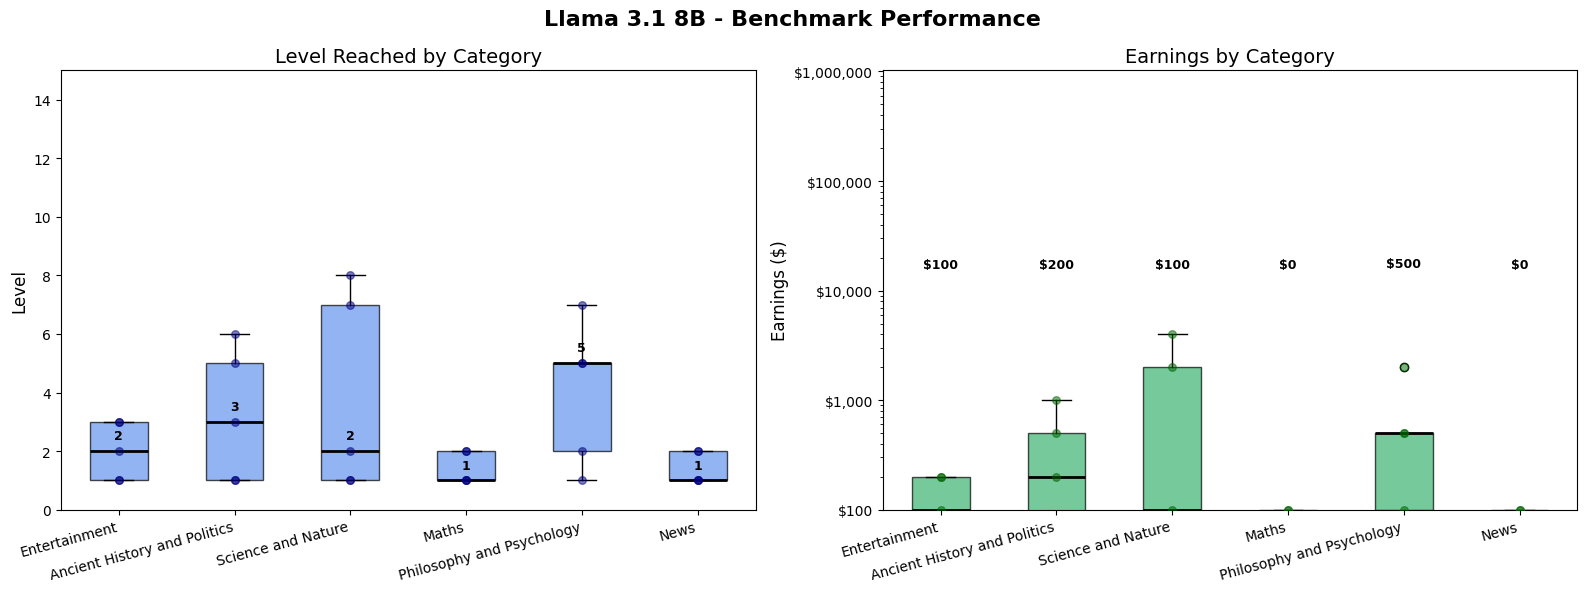

In [ ]:
plot_benchmark_results(experiment_data_1)

the results as expected are not very good. This happen because we don't give to the model the opportunity to reason about the choice. In so few tokens sometimes the model didn't even write the answer number forcing the code to default to 0.



### CoT experiment
Let's try again, this time we don't force the model to give straight away the correct option number but we let it reason writing some lines (CoT) and then we extract the aswer from them. so from previous code we modify the prompt and increase max_new_tokens.

Doing some tests with a timer we can see the model generates more or less 12 tokens per second. For the Math we need as much time/tokens as possible, to stay safe 25s which is more or less 300 max tokens.

In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

# experiment parameters
MAX_TOKENS = 300
IS_COT = True
USE_FEW_SHOT = False
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_2 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: Which of the following best describes the relationship between Batman and the Joker in The Dark Knight?

  [0] Batman and the Joker are romantic partners
  [1] Batman and the Joker are mortal enemies
  [2] Batman and the Joker are allies
  [3] Batman and the Joker are friends

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[Model Thought Process]:
The Joker and Batman are portrayed as arch-nemesis, with the Joker's chaotic and anarchic nature being a direct contrast to Batman's order and justice-driven personality, making them mortal enemies. This dynamic is a central theme in The Dark Knight.

FINAL_ANSWER: 1

 [System] Agent chose option: [1] (Time: 5.72s)
Game Server Time Left: 24.2 seconds
 CORRECT!
 Earned so far: $100.00

--- Level 2 (Categoria: 0) ---
Q: Which of the following statements best describes Michael Jackson's philanthropic work?

  [0] He refused to donate to any charities.
  [1] He organized numerous benefit concerts and donated significant sums of money.
  [2] He donated a small amount of money to charities.
  [3] He only supported local charities in his hometown.

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE

[Model Thought Process]:
Michael Jackson was known for his extensive philanthropic efforts, including organizing the "He

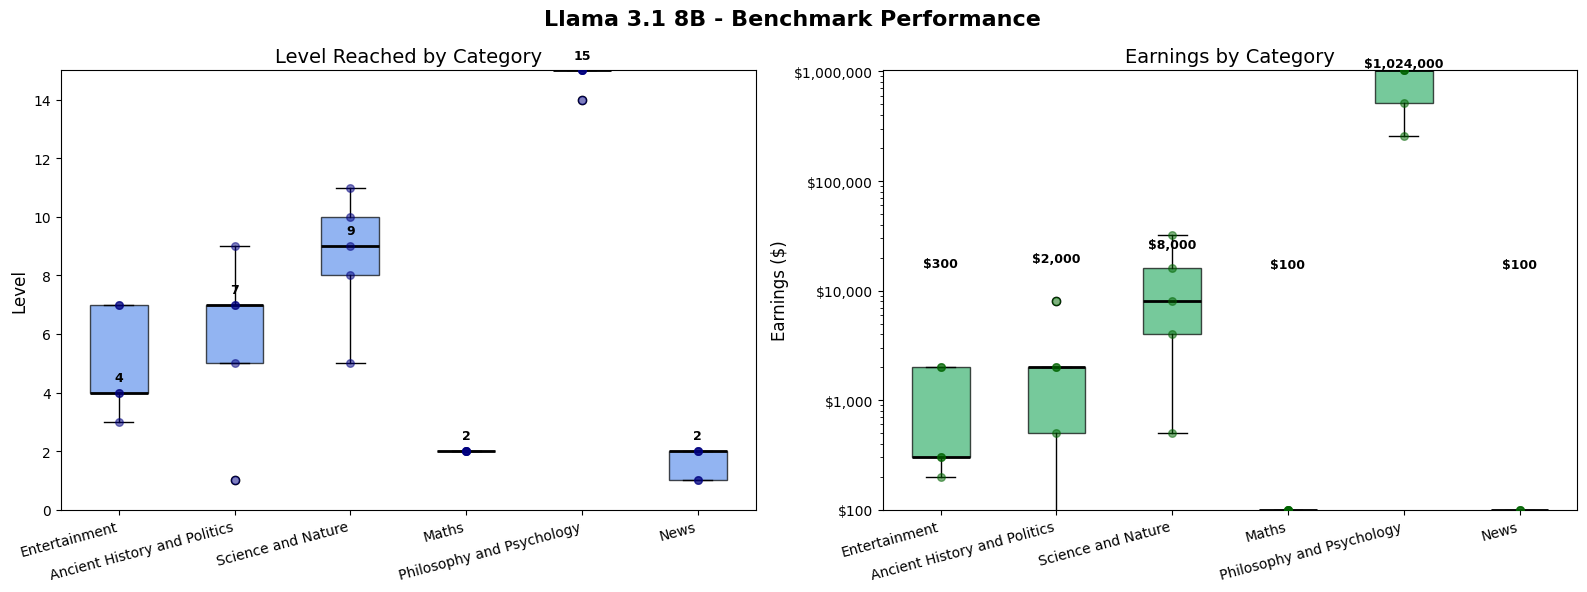

In [ ]:
plot_benchmark_results(experiment_data_2)

with CoT we obtain better rusults but there are still some problems.
let's see what happens in the log topic by topic:

*   **Entertainment**: The model has a solid baseline of pop-culture knowledge but struggles with highly specific niche facts.
*   **Ancient History and Politics**: same as entertainments, the model trips on highly specific historical events
*   **Science and Nature**: The model has the theory knowledge for reaching good results (even going near to win the game). the problem is when questions require complex applied physics knowledge or embedded arithmetic.
*   **Math**: the model knows what to do, but sometimes the calculations are wrong and most of the time the problem is token starvation. The model reson on the problem but end the tokens before submitting his solution causing the program to default the solution to 0 making the outcome random. We need more tokens but we are restricted by the 30s time limitation.
*   **Philosophy and Psychology**: in this topic the model obtain the better rusults also winning the game. It only tripped up on some deepest academic nuances. The questions are purely text-based, logical, and definitional subjects, perfect for the model to express his potential without tripping on some math-like questions.
*   **News**: the model refuse to answer. Because the model's training data cuts off in the past, its safety and hallucination-prevention guardrails kick in.
so the program fall back to the default answer (0) making the game outcome completely random.
> "I'm unable to verify the information about the article published on 2026-05-17... Since I don't have enough information to make a decision, I will not provide an answer."

**General Problems**

The model sometimes if it doesn't know the answer enters a repetition loop and forget to even try answering.

> **Q: Which musician is known for using the term 'rave' to describe the madness and frenzy of a feeling in a 1958 hit song?**
>
>   [0] Keith Moon
>   [1] Buddy Holly
>   [2] Mick Mulligan
>   [3] Steve Marriott
>
> **[Model Thought Process]:**
> The term 'rave' is closely associated with the song "La Bamba" by Ritchie Valens, but the song that is most famously linked to the term 'rave' is "La Bamba" is not the answer here, however, the song that is most famously linked to the term 'rave' is "La Bamba" is not the answer here, however, the song that is most famously linked to the term 'rave' is "La Bamba" ...
>
> *Warning: CoT format failed. Executing fallback.*
> Llama chose option: [0]

other times what happens is "label confusion": the model gives the right answer in the resoning but then it continue generating the CoT and in the end gives a wrong answer forgetting to connect the reasoning with the final answer.

> **Q: Which of the following correctly lists the organizational hierarchy of organisms from simplest to most complex?**
>
> [0] tissues, cells, organs, organ systems, organisms
> [1] cells, organs, tissues, organ systems, organisms
> [2] tissues, organs, cells, organ systems, organisms
> [3] cells, tissues, organs, organ systems, organisms
>
> *model is thinking...*
>
> **[Model Thought Process]:**
> The correct order from simplest to most complex is cells, tissues, organs, organ systems, and organisms. This is because cells are the basic building blocks of life, tissues are groups of similar cells, organs are groups of tissues, organ systems are groups of organs, and organisms are the complete living beings.
>
> FINAL_ANSWER: 0
>
> Llama chose option: [0]
>
> **WRONG ANSWER!**

we can try to solve these problems with a better prompt:

*   we ask the model to state which option matches his conclusion.
*   we tell the model to not repeat itself and if he is uncertant to pick the most plausible answer.

also we can try to solve some topic-specific problems
*  For math we need the model to reason but also to commit befoure finishing the tokens so we give him a limit of lines.
*  For news even if the model can't access the news because in a future date respect his data, we are playing a game and so he can't refuse to play. it's better a guessing answer based on his knowledge about the entities in the news than a no-answer.


In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = """You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences and state which option text matches your conclusion.
If you are uncertain, pick the most plausible option and commit, do not hedge and never repeat yourself.
For News questions: you may not have access to the specific article, but don't refuse to answer, use your knowledge about the entities, locations, and context mentioned to pick the most plausible option. Always commit to an answer.
For Math questions: show your reasoning step by step, but use NO MORE THAN 6 lines. After your reasoning you MUST commit to an answer immediately.
Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."""
# experiment parameters
MAX_TOKENS = 300
IS_COT = True
USE_FEW_SHOT = False
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_3 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: Which of the following best describes Prince's influence on modern popular music?

  [0] He was primarily influential in classical music
  [1] He was only influential in the 1980s
  [2] He is considered one of the most influential musicians of his generation
  [3] He had little impact on the music industry

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



[Model Thought Process]:
Prince's influence on modern popular music is multifaceted and far-reaching, spanning multiple genres and decades. He was a prolific artist who experimented with various styles, from rock to funk to R&B, and his innovative approach to music production, songwriting, and performance has inspired countless artists.

My conclusion is that Prince's influence is not limited to a specific genre or era, making option [2] the most accurate description of his impact on modern popular music.

FINAL_ANSWER: 2

 [System] Agent chose option: [2] (Time: 9.83s)
Game Server Time Left: 20.1 seconds
 CORRECT!
 Earned so far: $100.00

--- Level 2 (Categoria: 0) ---
Q: What is the fundamental principle of Leonardo DiCaprio's career that has contributed to his success?

  [0] Challenging himself with complex, demanding roles
  [1] Focusing on romantic comedies
  [2] Sticking to small, independent films
  [3] Avoiding roles in major blockbusters

[System] Routing the question to the

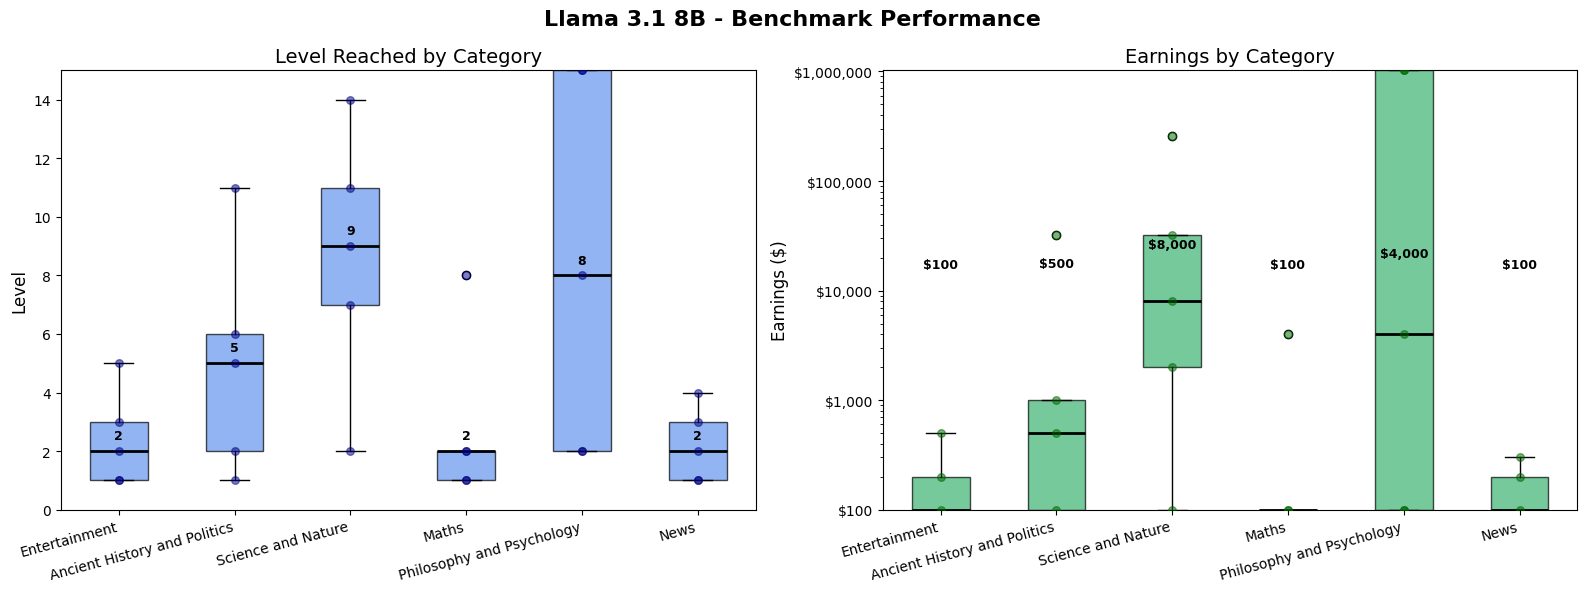

In [ ]:
plot_benchmark_results(experiment_data_3)

* **News guessing**: The prompt worked for news, now the model try to answer. anyway the model lack in knoledge and the guessing have poor performance
* **choking the reasoning**: The "commit and don't hedge" instruction actually hurts some topics removing the healthy caution that helped in the previous experimets in entertainment, history. And also in Philosophy where careful elimination of wrong options is the winning strategy.
* Did not worked for math who still struggles with tokens limitations and wrong arithmetics
* **Attention Dilution**: giving to many rules, the model attention struggles to remember them all, and finish to forget something like completely omit the FINAL_ANSWER: X tag.



### Few-Shot CoT Experiments

it's clear we can't rely only on the prompt itself, we must show the model how to respond.

* Format instability: the model occasionally omits FINAL_ANSWER: or writes the computed value instead of the option ID
* Reasoning style mismatch: the universal CoT prompt cannot optimally serve all categories, which require different approaches: systematic elimination for Philosophy, compact calculation for Maths, and entity-based inference for News

Few-shot examples address these issues not by providing new knowledge, but by demonstrating the expected behavior before the real question:

* Topic priming: examples per category anchors the reasoning style through imitation.
* Format anchoring: the model follows demonstrated output format more reliably

let's use the first CoT simple prompt and see if few-shot can help us:


In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

# experiment parameters
MAX_TOKENS = 300
IS_COT = True
USE_FEW_SHOT = True
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_4 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB, #fewshotDB
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: What was the primary reason Michael Jackson's 'Black or White' music video was controversial?

  [0] It was criticized for its lack of musical content.
  [1] It was too short and lacked detail.
  [2] It was the first music video to feature a racially diverse cast.
  [3] It included scenes of vandalism and violence.

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[Model Thought Process]:
The music video for 'Black or White' was criticized for its depiction of scenes of vandalism and violence, including smashing and breaking objects. Option [3] matches.
FINAL_ANSWER: 3

 [System] Agent chose option: [3] (Time: 8.06s)
Game Server Time Left: 21.9 seconds
 CORRECT!
 Earned so far: $100.00

--- Level 2 (Categoria: 0) ---
Q: What is the fundamental principle of bebop in jazz?

  [0] Innovative and complex harmonic and rhythmic structures
  [1] Emphasis on slow, deliberate tempos
  [2] Use of only traditional instruments
  [3] Strict adherence to the melody

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE

[Model Thought Process]:
Bebop is characterized by its fast tempos and complex, intricate melodies and harmonies, making option [0] the correct answer. 
FINAL_ANSWER: 0

 [System] Agent chose option: [0] (Time: 6.41s)
Game Server Time Left: 23.5 seconds
 CORRECT!
 Earned so far: $200.00

--- Leve

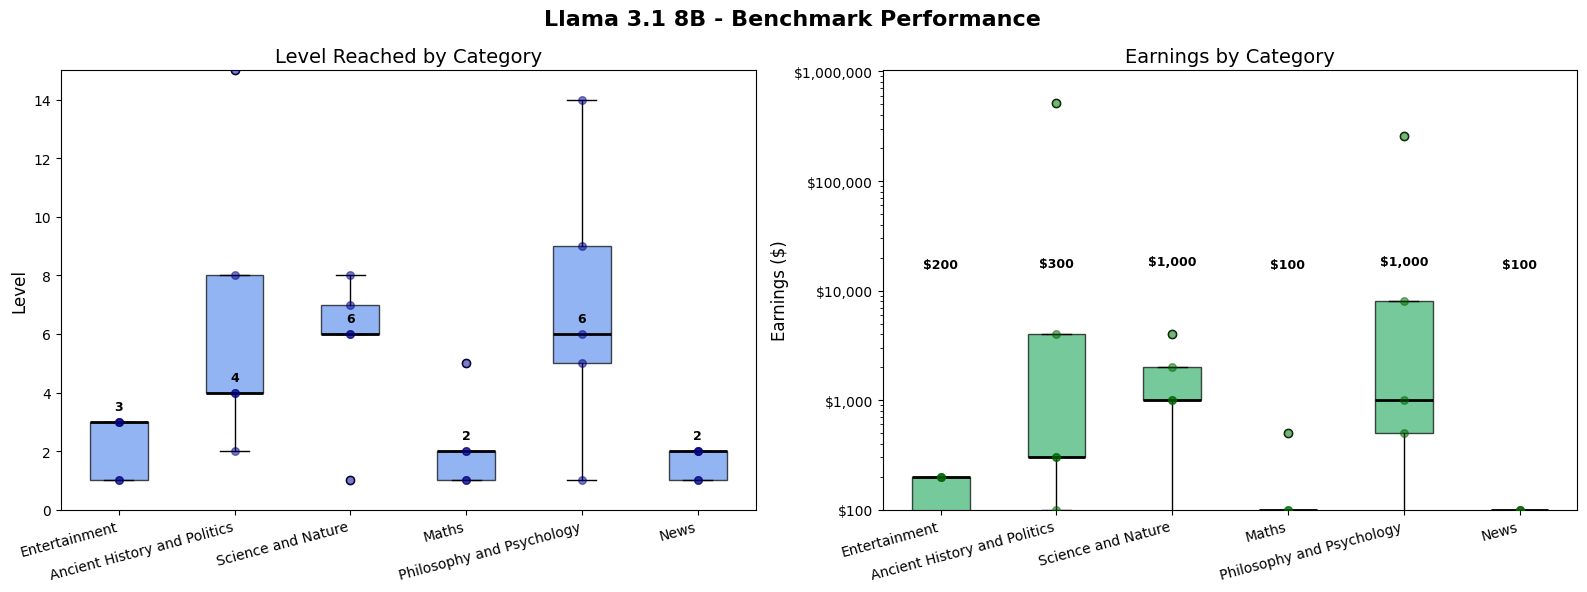

In [ ]:
plot_benchmark_results(experiment_data_4)

From the theory we would expect better results adding few-shot, but here we see the opposite result.

From the log we see that:
* Adding two CoT examples per topic significantly increases the input token length of your prompt. A longer input means more time to process the input and less time to reason and answer.
* But the real killer is the **attention diluition**, a small model like ours focus too much on the big input and lose track of the current task.

Giving two examples is nocive in terms of **context length**.
We could try **one-shot** and see if we obtain some benefit if we reduce the context legth:

In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

# experiment parameters
MAX_TOKENS = 300
IS_COT = True
USE_FEW_SHOT = True
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_5 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB1, #one-shot
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: Which of the following best describes the fundamental principle of Italian Neorealism?

  [0] Films aimed to showcase the luxurious lifestyles of the wealthy in Italy.
  [1] Films were primarily shot in studios with professional actors.
  [2] Stories focused on the lives of the poor and working class in post-World War II Italy.
  [3] Films were primarily set in Hollywood and depicted American life.

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[Model Thought Process]:
Italian Neorealism was a cinematic movement that emerged in post-World War II Italy, focusing on realistic portrayals of everyday life, particularly the struggles and hardships faced by the working class. Therefore, it makes sense that the movement would focus on the lives of the poor and working class in post-war Italy. Option [2] aligns with this description.
FINAL_ANSWER: 2

 [System] Agent chose option: [2] (Time: 6.40s)
Game Server Time Left: 23.5 seconds
 CORRECT!
 Earned so far: $100.00

--- Level 2 (Categoria: 0) ---
Q: What is the term used for the words of an opera?

  [0] Libretto
  [1] Chorus
  [2] Recitative
  [3] Aria

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE

[Model Thought Process]:
The term used for the words of an opera is the libretto. It is the text of an opera, which includes the dialogue and lyrics of the characters. 
FINAL_ANSWER: 0

 [System] Agent chose option: [0] (Time: 4.14

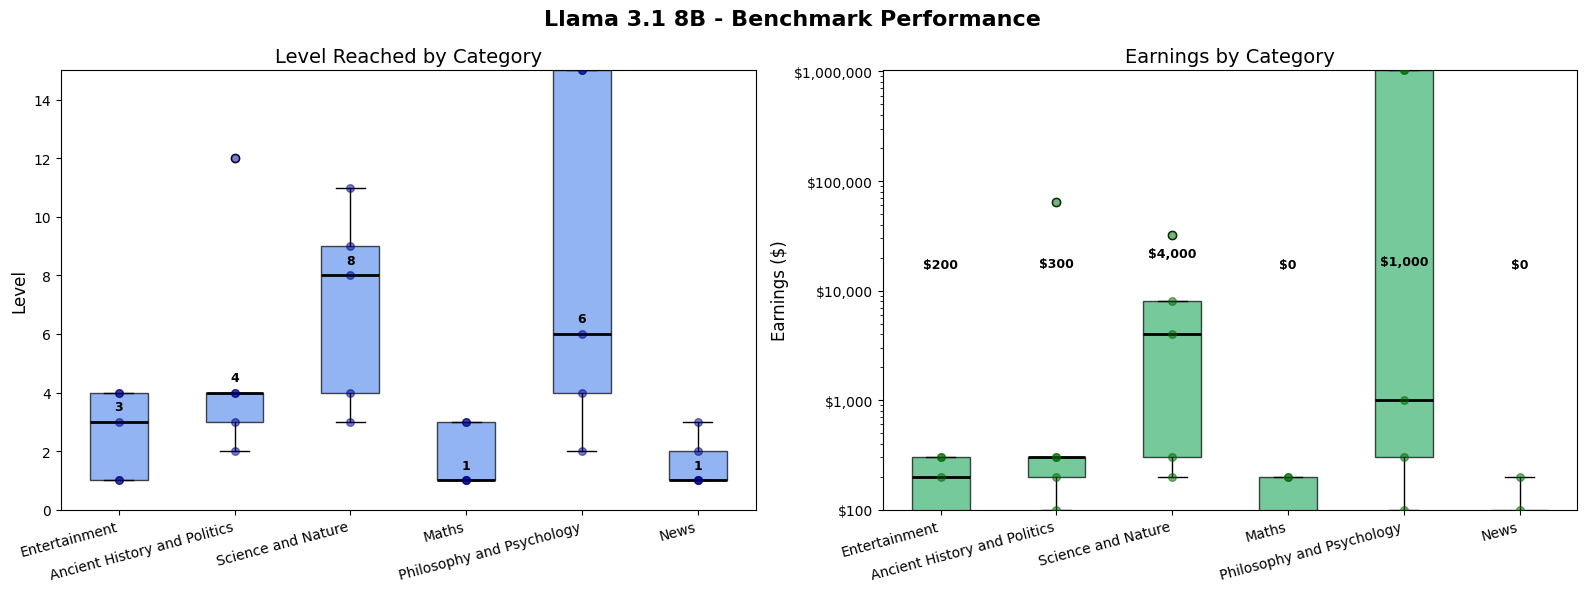

In [ ]:
plot_benchmark_results(experiment_data_5)

Even the one-shot does not give good resutls. possible explanation:
*  The model use its processing power trying following the example pattern and has less brainpower left to actually retrive the correct facts. For a small model like 8B llama is better use all the computing power in the generation even if the format is not always respected.
*  Forced hallucination: By using one-shot, we showed the model that it must write a confident, multi-sentence logical explanation for every single answer. When it encountere a question is unsure about, the prompt forces it to yap. It starts writing a plausible-sounding explanation to satisfy your structural requirement. And it convices itself in a wrong answer.


### One-shot no CoT experiment
For comparison let's see what happens if we use one-shot without CoT:

In [ ]:
# CONTROL PANEL

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

# experiment parameters
MAX_TOKENS = 300
IS_COT = False
USE_FEW_SHOT = True
IS_RAG= False
IS_AGENT = False
NUM_GAMES = 5

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

#execute benchmark that run for every competition NUM_GAMES and pick the median result
experiment_data_1 = run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Entertainment (ID: 0) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 0) ---
Q: Which of the following best describes the concept of 'psychedelic pop' that was used to categorize Pink Floyd in the late 1960s?

  [0] Music that focuses solely on psychedelic visuals
  [1] Music that incorporates psychedelic sound effects and themes
  [2] Music that combines psychedelic and folk elements
  [3] Music that is purely experimental and avant-garde

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


 [System] Agent chose option: [2] (Time: 6.26s)
Game Server Time Left: 23.7 seconds
 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 2/5 ---

--- Level 1 (Categoria: 0) ---
Q: Which of the following best describes Thanos' relationship with his children, Gamora and Nebula?

  [0] He dislikes them and tries to get rid of them
  [1] He treats them as equals and shares his plans with them
  [2] He considers them orphans and adopts them
  [3] He loves them unconditionally

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE
 [System] Agent chose option: [0] (Time: 4.16s)
Game Server Time Left: 25.8 seconds
 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 3/5 ---

--- Level 1 (Categoria: 0) ---
Q: What term describes Humphrey Bogart's birth date as originally recor

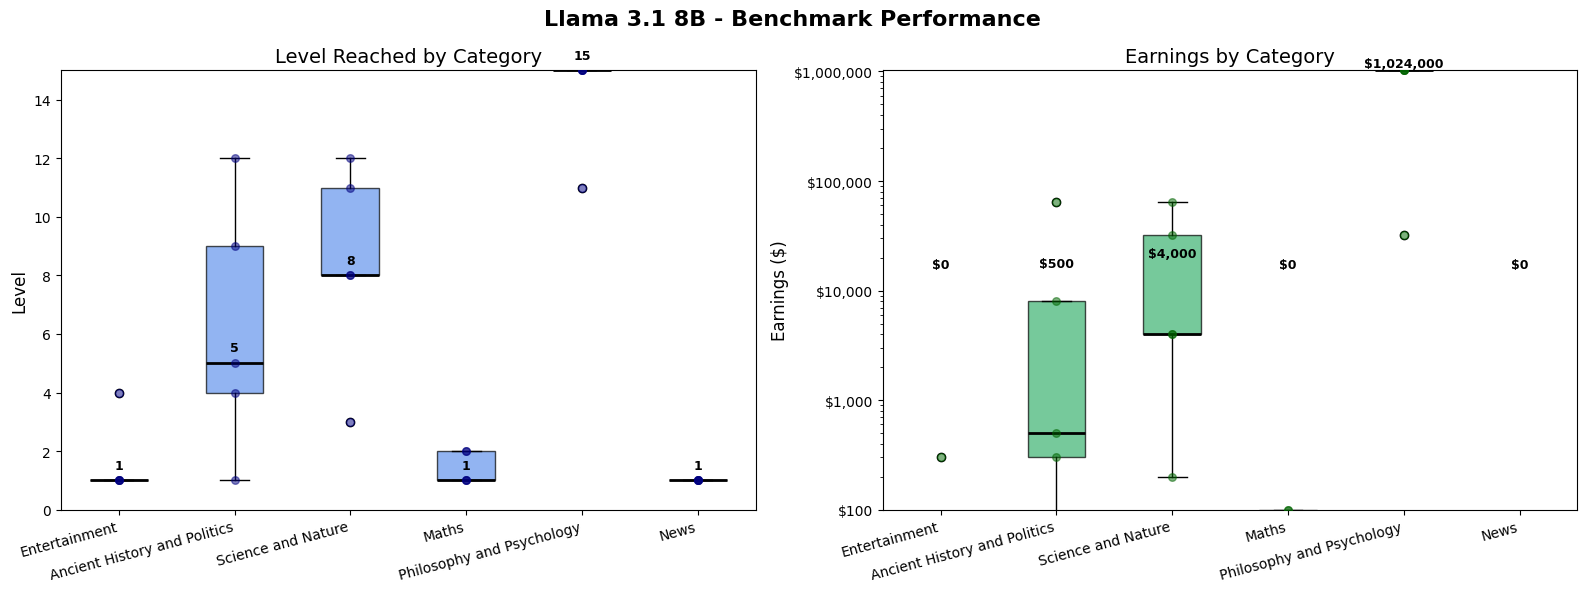

In [ ]:
plot_benchmark_results(experiment_data_6)

From the results we can appreciate the benefit of one-shot that we can't see using it with the CoT. we even win in philosophy.


### Prompt Engineering Conclusions

In [ ]:
plot_comparison({
    "Zero-shot no-CoT": experiment_data_1,
    "Zero-shot CoT":    experiment_data_2,
    "One-shot CoT":     experiment_data_5,
    "One-shot no-CoT":  experiment_data_6,
})


* **Chain-of-Thought is essential**, Zero-shot no-CoT is the weakest
configuration.
* **one-shot can help**: without CoT we can see oneshot helping with priming and formatting.
* **Model overwhelming**: if we use few-shot or CoT and oneshot togheter we obtain worse results hitting a cognitive ceeling. Same thing if we use a long complex prompt.
* **Maths is hard:** we don't see significant changes in the performances usinrg or not CoT and fewshot. That's because the model don't have enough time/tokens to think/write the solution. from the log beside the token budget sometimes we see the model do errors in the calculation even if the reasoing is correct. Adding a **Calculator** (or other agentic solution) would help the performance  


* **knowledge problem** The results reveals that the primary bottleneck is **knowledge**, not format
or reasoning style. Looking at the game logs, many questions contain phrases like
"according to the article" or ask about very specific information the model has never seen.
Prompting techniques, CoT, few-shot, one-shot, can only work with knowledge the
model already has. They cannot supply missing information. This motivates the
introduction of **Retrieval-Augmented Generation (RAG)**

## RAG Experiments

###News RAG Experiments

####How News RAG works:
* The RAG module for the News category retrieves 1 web page from the web with a Tavily API connection using as a search querty the question and the options from the quiz. Some regex parsing to extract the date is applied, to make the search more precise.
* The raw page from the web-page is then summarized by the Llama model.
* The summary is then passed the Llama main instance which will answear the question from the quiz.

We desided to do the test on the News RAG because the Enteritaiment and NewsRag use the same architecture and modules. The News RAG is a little more difficult and that is why we chose it for the testing.

####First News RAG Experiment
In this first experiment I want to test if adding knowledge from external sources imroves the performances.
I will test the performance in 4 configurations:
First Configuration:
*   Basic Prompt
*   NO CoT
*   NO Few Shots
*   Without RAG

Second Configuration:
Basic Prompt
*   NO CoT
*   NO Few Shots
*   With RAG

Third Configuration:
*   Basic Prompt
*   CoT
*   Few Shots
*   Without RAG

Fourth Configuration:
*   Basic Prompt
*   CoT
*   Few Shots
*   With RAG




#####Code for testing First News RAG Experiment

In [ ]:
#FIRST CONFIGURATION: NO Cot, NO Few-Shot, NO Rag
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = False,
    is_rag = False,
    is_agent = False
)

experiment_news_rag_1_1= run_benchmark(
    game_client=game_client,
    mode="text",
    num_games=5,
    use_few_shot=False,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: News (ID: 5) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 5) ---
Q: What did the study published on 2026-05-13 suggest about the prevalence of obesity in high-income countries compared to 1980?

  [0] It had decreased significantly
  [1] It had doubled
  [2] It had remained constant
  [3] It had plateaued or slowed

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


 [System] Agent chose option: [1] (Time: 8.26s)

 [System] Reasoning: [None]

 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 2/5 ---

--- Level 1 (Categoria: 5) ---
Q: According to the article published on 2026-05-11, what type of word puzzle did Alex Bellos provide to his readers?

  [0] Homonym
  [1] Crossword
  [2] Cryptogram
  [3] Anagram

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE
 [System] Agent chose option: [1] (Time: 18.57s)

 [System] Reasoning: [None]

 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 3/5 ---

--- Level 1 (Categoria: 5) ---
Q: According to the article published on 2026-05-14, who was awarded the Charlemagne Prize in Aachen, Germany?

  [0] Volodymyr Zelensky
  [1] Angela Merkel
  [2] Mario Draghi
  [3] Friedrich Merz

[Sy

In [ ]:
#SECOND CONFIGURATION: NO Cot, NO Few-Shot, Rag
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = False,
    is_rag = True,
    is_agent = False
)

experiment_news_rag_1_2= run_benchmark(
    game_client=game_client,
    mode="text",
    num_games=5,
    use_few_shot=False,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: News (ID: 5) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 5) ---
Q: According to the article published on 2026-05-18, which book won the book of the year at the NSW literary awards?

  [0] Näku Dhäruk: The Bark Petitions
  [1] Forgotten Rebels of Eureka
  [2] Gone
  [3] The Narrow Road to the Deep North

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to specialist: GENERAL WEB RAG MODULE
  --RETRIEVAL-- Searching OPEN WEB (NEWS) via Tavily for: 'According to the article published on 2026-05-18, which book won the book of the year at the NSW literary awards?'
  [Time Filter] Searching from 2026-05-18 to 2026-05-19
   [WEB RAG] Context downloaded! Sending to the LLM to generate the final answer...
   [CONTEXT]: The book that won the book of the year at the NSW literary awards is not mentioned in the provided data sources. The sources focus on various book acquisitions and award

In [ ]:
#THIRD CONFIGURATION: Cot, Few-Shot, NO Rag
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = True,
    is_rag = False,
    is_agent = False
)

experiment_news_rag_1_3= run_benchmark(
    game_client=game_client,
    mode="text",
    num_games=5,
    use_few_shot=True,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: News (ID: 5) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 5) ---
Q: According to the report published on 2026-05-16, which cruise ship was involved in the hantavirus outbreak?

  [0] MS Europa 2
  [1] Norwegian Sky
  [2] Queen Elizabeth
  [3] MV Hondius

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE

[Model Thought Process]:
I'm unable to verify the information about the hantavirus outbreak on a cruise ship.

  [Parsing Warning] CoT format failed. Executing fallback.
 [System] Agent chose option: [0] (Time: 2.10s)

 [System] Reasoning: [None]

 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 2/5 ---

--- Level 1 (Categoria: 5) ---
Q: According to the report from 2026-05-14, how much money was alleged to have been laundered by the group Yermak is accused of being a p

In [ ]:
#FOURTH CONFIGURATION: Cot, Few-Shot, NO Rag
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = True,
    is_rag = True,
    is_agent = False
)

experiment_news_rag_1_4= run_benchmark(
    game_client=game_client,
    mode="text",
    num_games=5,
    use_few_shot=True,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: News (ID: 5) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 5) ---
Q: The article published on 2026-05-08 mentions that 'Fatherland' explores the relationship between Thomas Mann and his daughter Erika. Who played Erika Mann in the film?

  [0] Emma Stone
  [1] Kate Winslet
  [2] Sandra Hüller
  [3] Cate Blanchett

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to specialist: GENERAL WEB RAG MODULE
  --RETRIEVAL-- Searching OPEN WEB (NEWS) via Tavily for: 'The article published on 2026-05-08 mentions that 'Fatherland' explores the relationship between Thomas Mann and his daughter Erika. Who played Erika Mann in the film?'
  [Time Filter] Searching from 2026-05-08 to 2026-05-09
   [WEB RAG] Context downloaded! Sending to the LLM to generate the final answer...
   [CONTEXT]: Sandra Hüller played Erika Mann in the film 'Fatherland'.

[Model Thought Process]:
The film 'Fatherland' 

#####Results First News RAG Experiment

/tmp/ipykernel_6106/4124697460.py:43: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


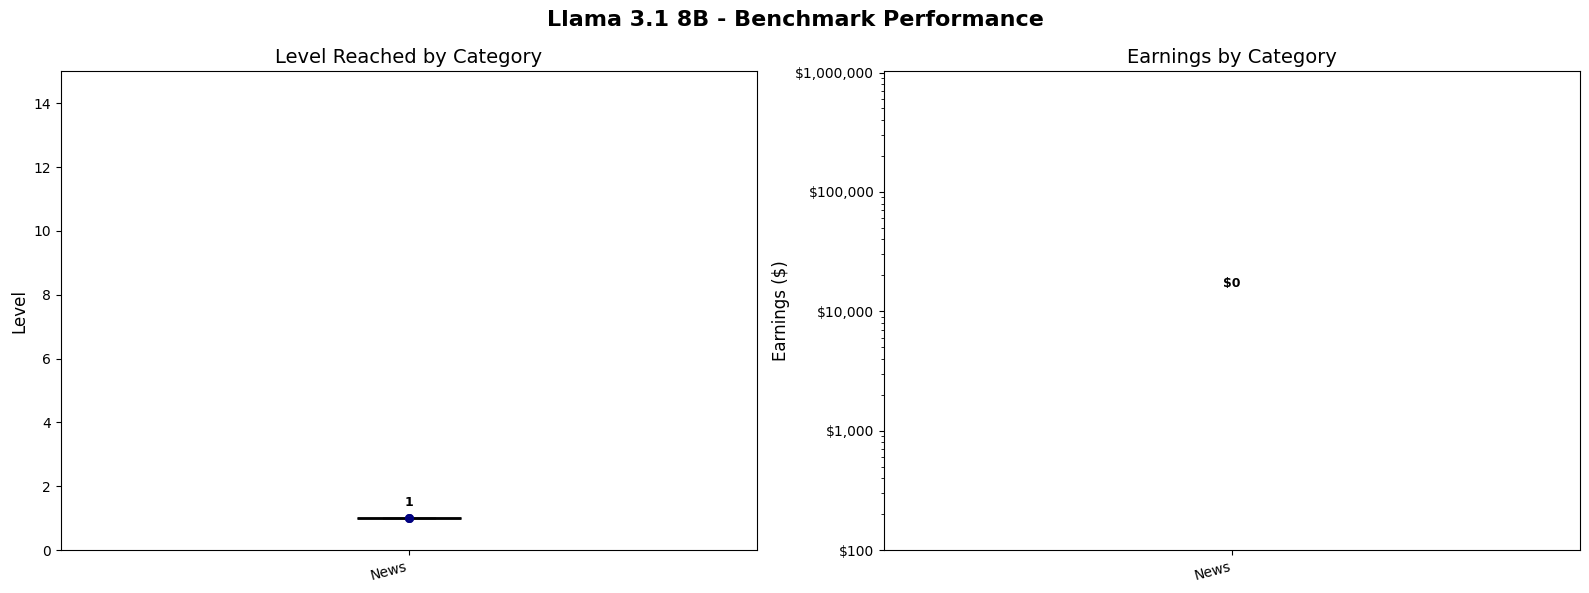

In [ ]:
plot_benchmark_results(experiment_news_rag_1_1)
#FIRST CONFIGURATION: NO Cot, NO Few-Shot, NO Rag

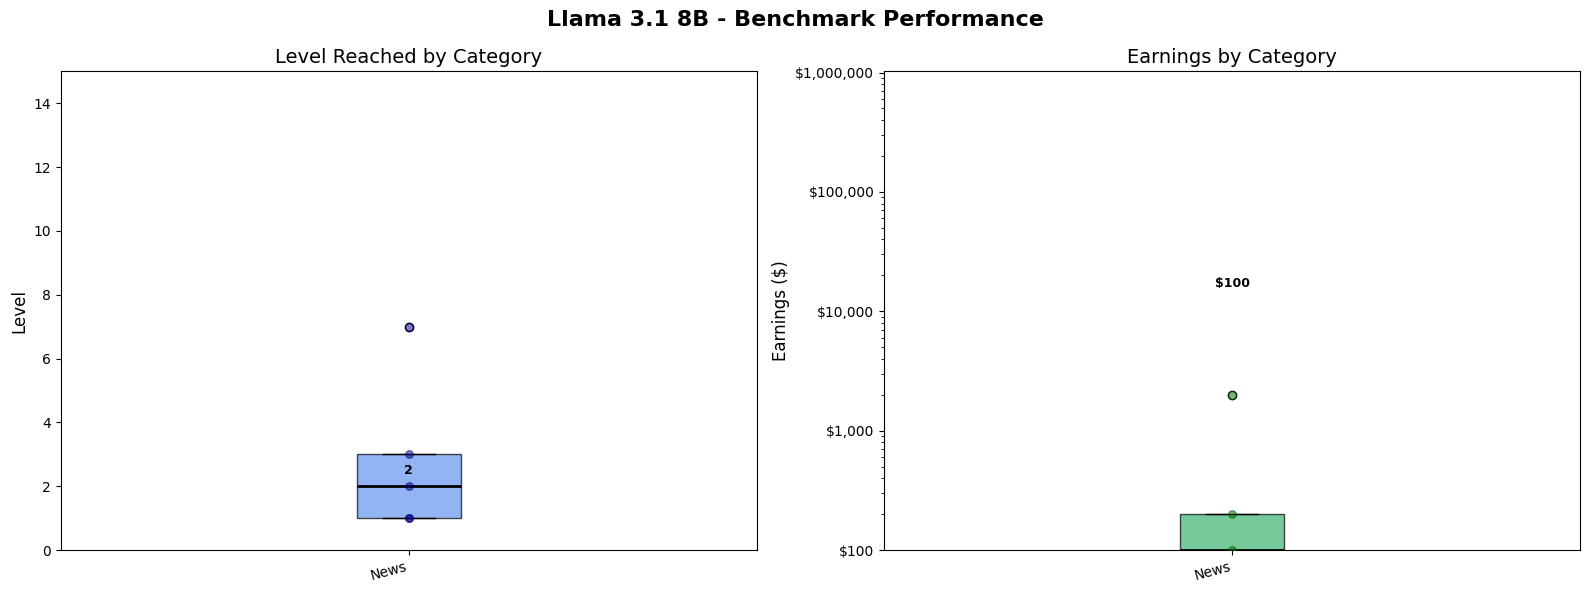

In [ ]:
plot_benchmark_results(experiment_news_rag_1_2)
#SECOND CONFIGURATION: NO Cot, NO Few-Shot, WITH Rag

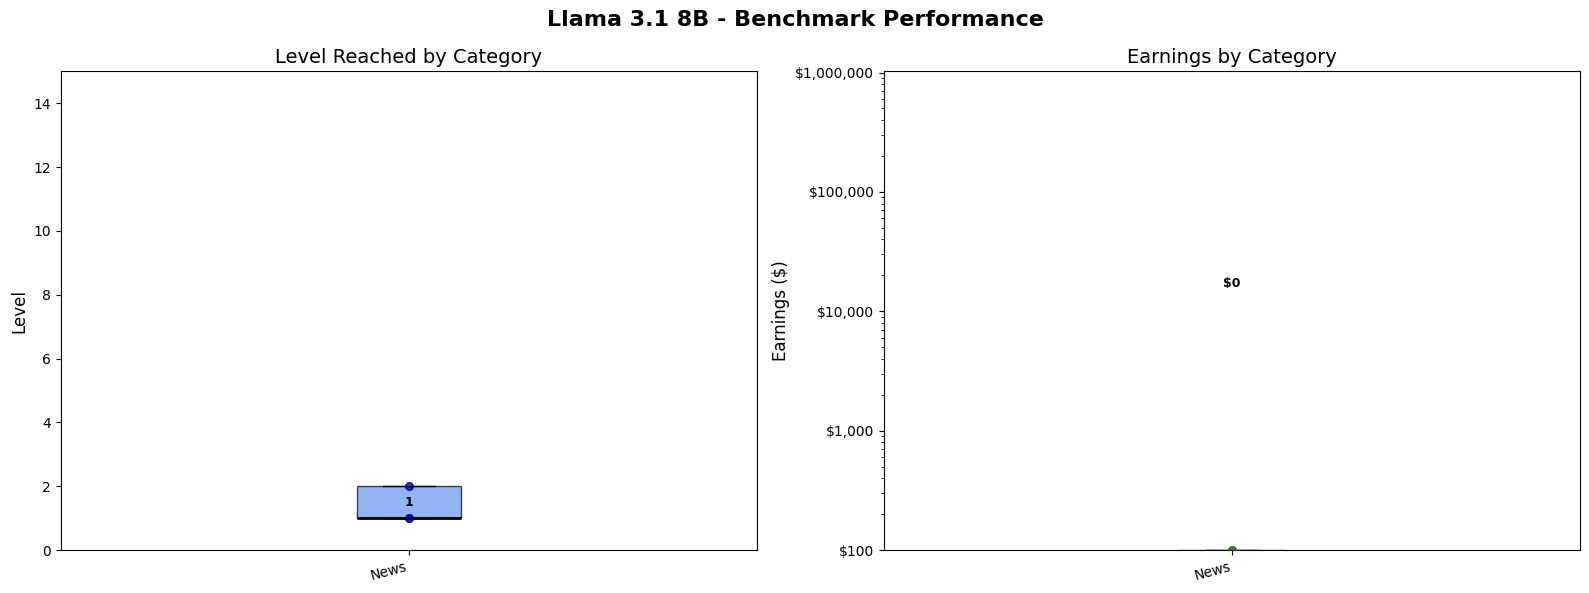

In [ ]:
plot_benchmark_results(experiment_news_rag_1_3)
#THIRD CONFIGURATION: WITH Cot, WITH Few-Shot, NO Rag

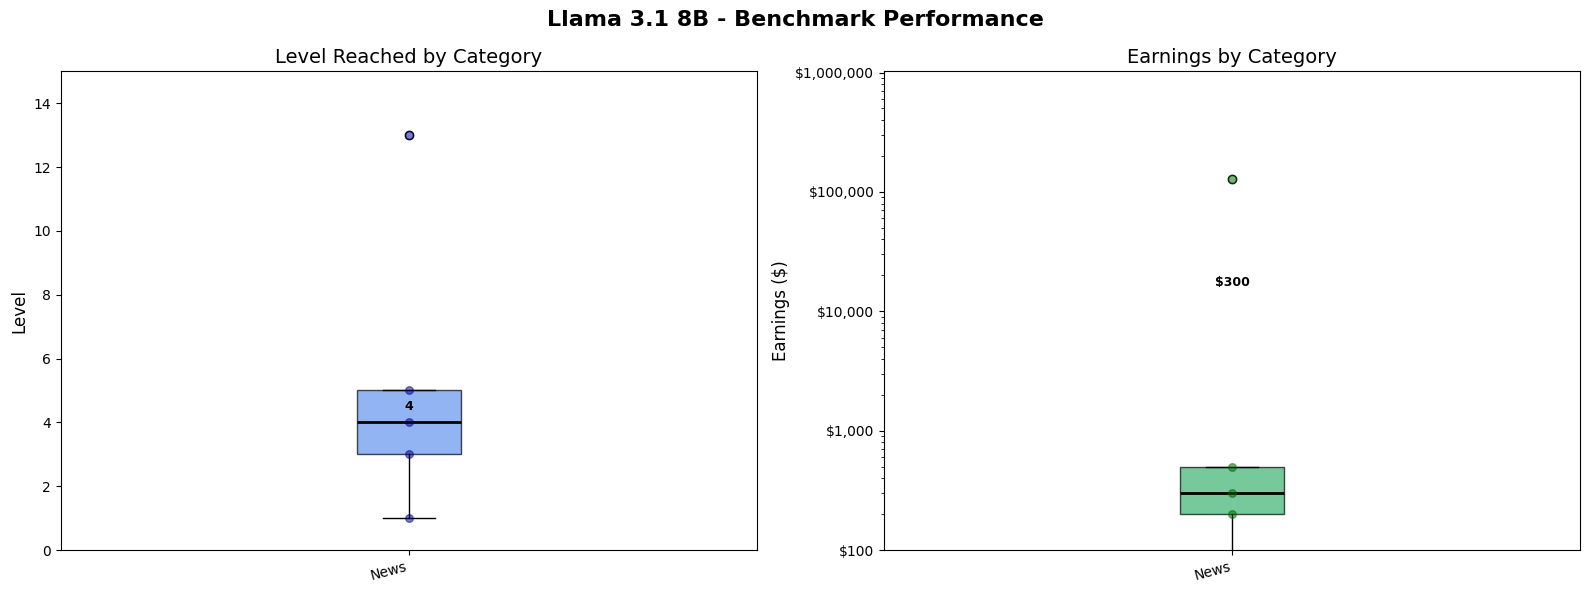

In [ ]:
plot_benchmark_results(experiment_news_rag_1_4)
#FOURTH CONFIGURATION: WITH Cot, WITH Few-Shot, WITH Rag

#####Conclusion and observation of First News RAG Experiment:
We observed that RAG's information profoundly impacts the performance of the system.
*   It is clear with the comparison of Configuration 1 with Configuration 2 results in which the system passed from a 1 Level peformance to a substained 2 to 3 Level peformane. We can also see a game in which the system achived 7.

*   It is even more clear with the comparison of Configuration 3 with Configuration 4 results. In this comparing we see a big increase in the achieved levels. Notably with Configuration 4 there is a game in which the system achived 13.

We can deduct that for the model we used (Llama 3.1 8B) introducing a RAG module increases the model performance.




####Second News Rag Experiment
This test is to check if the addition of the Web News Rag Module increases or decreases the time needed by the system to respond to the quiz questions.

For this test I will use this setup I will first run this configuration:
*   Basic Prompt
*   CoT
*   Few Shots
*   NO Rag Agent

And then I will run this configuration:
*   Basic Prompt
*   CoT
*   Few Shots
*   Rag Agent



#####Code for second experiment without News Web RAG

In [ ]:
MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."
NUM_GAMES = 5

# experiment parameters
MAX_TOKENS = 200
IS_COT = True
USE_FEW_SHOT = True
IS_RAG= True
IS_AGENT = False
NUM_GAMES = NUM_GAMES

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

experiment_data_rag_2_a= run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Math (ID: 3) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 3) ---
Q: A telephone survey of 400 registered voters showed that 256 had not yet made up their minds 1 month before the election. How sure can we be that between 60% and 68% of the electorate were still undecided at that time?

  [0] 8.0%
  [1] 2.4%
  [2] 64.0%
  [3] 90.4%

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[Model Thought Process]:
The proportion of undecided voters is 256 / 400 = 0.64. To find the margin of error, I will use the formula for the standard error of a proportion: sqrt(p * (1 - p) / n). p is 0.64, n is 400. The standard error is sqrt(0.64 * (1 - 0.64) / 400) = sqrt(0.24 / 400) = sqrt(0.0006) = 0.024. To find the margin of error, I will multiply this by 1.96 (the z-score for a 95% confidence interval). The margin of error is 0.024 * 1.96 = 0.04704. To find the interval, I will subtract and add this to the proportion: 0.64 - 0.04704 = 0.59296 and 0.64 + 0.04704 = 0

  [Parsing Warning] CoT format failed. Executing fallback.
 [System] Agent chose option: [0] (Time: 24.62s)

 [System] Reasoning: [None]

 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00
 --- Starting Game 2/5 ---

--- Level 1 (Categoria: 3) ---
Q: Which of the following is an equation of the line tangent to the graph of y = x + e^x at x = 0 ?


#####Code for second experiment with News Web RAG

In [ ]:
MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and options carefully. Briefly explain your logic in 1 or 2 sentences. Then, on a new line, you MUST write exactly 'FINAL_ANSWER: X' where X is the integer ID (0, 1, 2, or 3) of the correct option."
NUM_GAMES = 5

# experiment parameters
MAX_TOKENS = 300
IS_COT = True
USE_FEW_SHOT = True
IS_RAG= True
IS_AGENT = False
NUM_GAMES = NUM_GAMES

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = MAX_TOKENS,
    is_cot = IS_COT,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

experiment_data_rag_2_b= run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=USE_FEW_SHOT,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config = None
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Math (ID: 3) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 3) ---
Q: A town has one high school, which buses students from urban, suburban, and rural communities. Which of the following samples is recommended in studying attitudes toward tracking of students in honors, regular, and below-grade classes?

  [0] Systematic sample
  [1] Stratified sample
  [2] Simple random sample (SRS)
  [3] Convenience sample

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to: STANDARD MODULE

[Model Thought Process]:
A stratified sample is recommended when studying attitudes toward tracking of students in honors, regular, and below-grade classes. This is because the population is divided into subgroups (strata) based on the type of community (urban, suburban, and rural), and a random sample is taken from each stratum. This ensures that each subgroup is adequately represented in the sample.
FINA

#####Results Second News RAG Experiment

######Results without using web News Rag

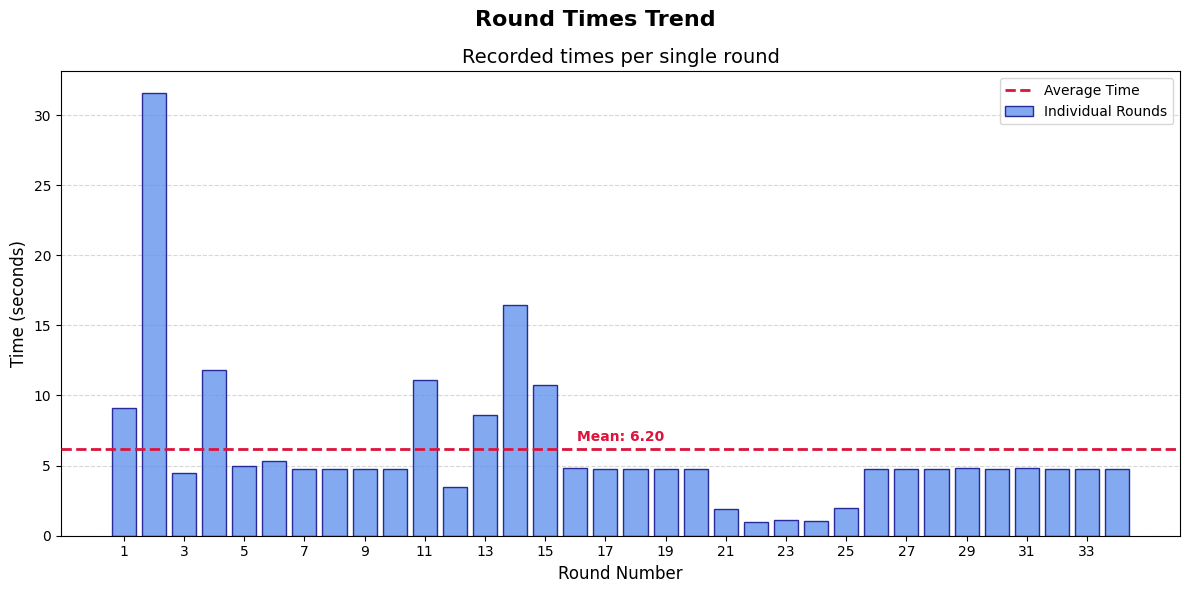

In [ ]:
plot_round_times(GAME_TIMES)

######Results using web News Rag with local model summarization

In [ ]:
plot_round_times(GAME_TIMES)

#####Conclusion and observation of Second News RAG Experiment
I can conclude from this experiment that using a RAG with an attached summarization step by an LLM increases the times most of the times not by a lot.
The little increase in mean time for respose justifies the increase benefit of increased performance.

### Local RAG Experiments

Let's test the local RAG with the different system prompts and search functions.

In [ ]:
MODE = "text"

SYS_PROMPT_PLAIN = sys_prompt_local_rag
SYS_PROMPT_EXPLAIN = sys_prompt_local_rag_explain
MAX_TOKENS_PLAIN = 10
MAX_TOKENS_EXPLAIN = 256
USE_FEW_SHOT = True
IS_RAG= True
IS_AGENT = False

NUM_GAMES = 5

llama_config_plain = LlamaConfig(
    sys_prompt = SYS_PROMPT_PLAIN,
    max_tokens = MAX_TOKENS_PLAIN,
    is_cot = False,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

llama_config_explain = LlamaConfig(
    sys_prompt = SYS_PROMPT_EXPLAIN,
    max_tokens = MAX_TOKENS_EXPLAIN,
    is_cot = True,
    is_rag = IS_RAG,
    is_agent = IS_AGENT
)

config = {
    "game_client": game_client,
    "mode": MODE,
    "num_games": NUM_GAMES,
    "use_few_shot": USE_FEW_SHOT,
    "examples_db": EXAMPLES_DB,
    "math_agent_config": None
}

In [ ]:
experiment_data_local_rag = run_benchmark(**config, llama_config=llama_config_plain)

In [ ]:
plot_benchmark_results(experiment_data_local_rag)

In [ ]:
experiment_data_local_rag_explain = run_benchmark(**config, llama_config=llama_config_explain)

In [ ]:
plot_benchmark_results(experiment_data_local_rag_explain)

Looking at the results, there isn't much evidence to conclude that adding knowledge from external documents improves performance. This may be because the model already has a lot of the knowledge it needs to answer simpler questions, whereas for harder questions the document collection does not provide much that can help.

For what concerns prompt engineering, the contrained reasoning we asked from the model in the "explain" version yelds similar results to the "plain" version.

Finally, by trying the different search functions, we can see that re-ranking has a big effect on performance, as we can also see from the quality of the retrieved documents. RRF also performs well.

Let's see some questions that The chatbot got wrong:

- Q: A student investigated the effect of the color of light on the growth of plants. Red, yellow, and green lights were used in the experiment. If another student were to conduct the same experiment, which would be the most important procedure to follow to yield the same results?

  [0] to do the investigation at the same time of year

  [1] to use the same chart for recording growth

  [2] to use the same colors of lights

  [3] to do the investigation in the same room

[Context]

"Conduct experiments or make observations to test the hypothesis."

[Model Thought Process]

0: Different seasons may affect growth. Therefore: Wrong.

1: Different charts may lead to different results. Therefore: Wrong.

2: Different colors may lead to different results. Therefore: Wrong.

3: Same room conditions ensure consistent results. Therefore: Right.

FINAL_ANSWER: 3

For this question the retrieved context doesn't help, and the model does some strange reasoning on the options, leading it to choosing the wrong option.

- Q: Which of the following best exemplifies a deductive argument?

  [0] If it rains, the streets will be wet; it is raining; therefore the streets are wet

  [1] Most elephants I have seen are gray, so this elephant must be gray

  [2] All frogs are amphibians; no cats are amphibians; therefore no cats are frogs

  [3] All ravens I have seen are black, so all ravens are black

[Context]

"Deduction
Deduction might mean:"

[Model Thought Process]

0: This is an example of a deductive argument as it follows a clear if-then structure. Therefore: Right.

1: This is an inductive argument as it generalizes from specific instances to a general rule. Therefore: Wrong.

2: This is an example of a deductive argument as it uses a syllogism. Therefore: Wrong.

3: This is an inductive argument as it generalizes from specific instances to a general rule. Therefore: Wrong.

FINAL_ANSWER: 0

Again the retrieved context is of no help, and the model makes some reasoning mistakes, saying that [2] is an deductive argument but concluding that it is not the correct option.

## Agent Experiments

###Math Agent Experiment
With this experiment I hope to adress three research qeustion:

1.   Test if bigger models perform better than smaller
2.   Test if bigger models perform better than smaller while using a tool with a ReAct Agent pattern

3.   Test if the same model is better if provided a tool with a ReAct Agent pattern




#####vLLM Server configuration for Qwen Model (1.5B -> 7B) without Tool Use

######Qwen2.5 (1.5B) (quantization: Instruct-GPTQ-Int4) (without Tool Use)

In [ ]:
INIT_VLLM_CMD = f"""
nohup python -m vllm.entrypoints.openai.api_server \
    --model "Qwen/Qwen2.5-1.5B-Instruct-GPTQ-Int4" \
    --dtype float16 \
    --max-model-len 8192 \
    --gpu-memory-utilization 0.75 \
    --trust-remote-code \
    --enforce-eager \
    --port 8000 > vllm.log 2>&1 &
"""
model_name="Qwen/Qwen2.5-1.5B-Instruct-GPTQ-Int4"

Test Results:

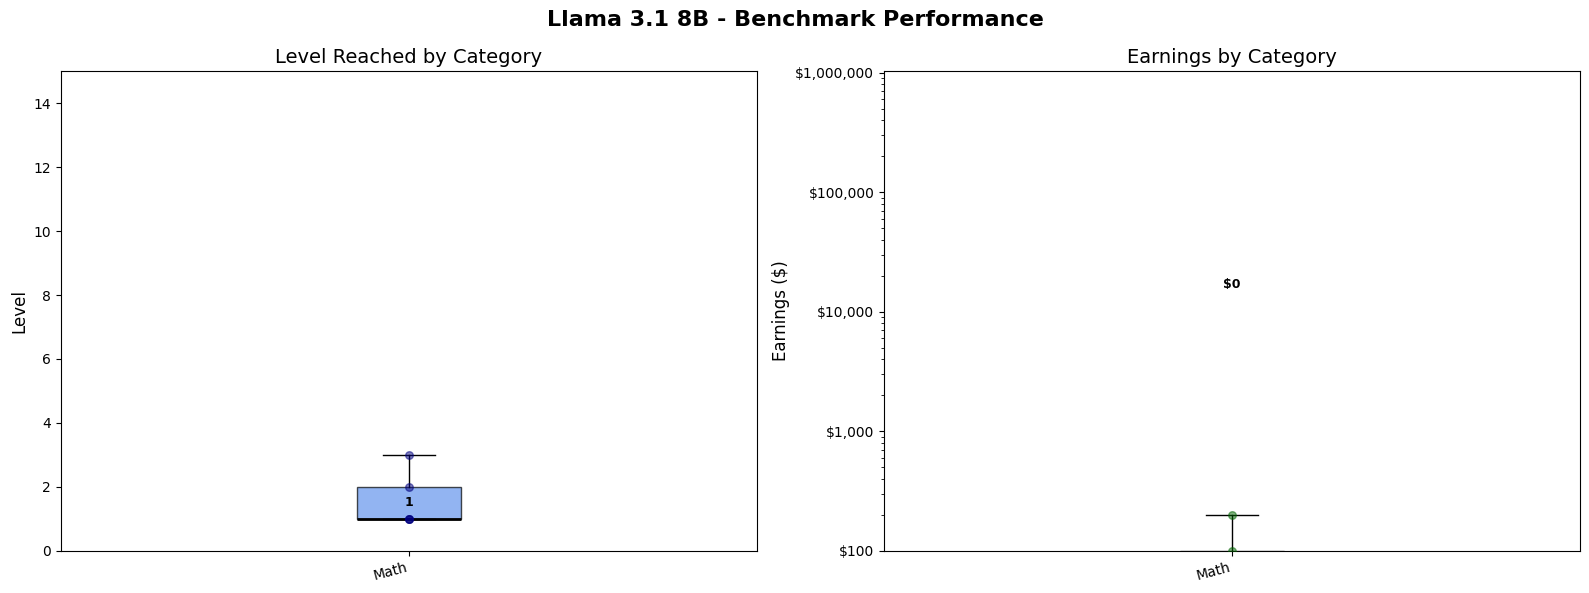

In [ ]:
plot_benchmark_results(experiment_data_agent_1)

######Qwen2.5 (7B) (quantization: Instruct-GPTQ-Int4) (without Tool Use)

In [ ]:
INIT_VLLM_CMD = f"""
nohup python -m vllm.entrypoints.openai.api_server \
    --model "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4" \
    --dtype float16 \
    --max-model-len 8192 \
    --gpu-memory-utilization 0.75 \
    --trust-remote-code \
    --enforce-eager \
    --port 8000 > vllm.log 2>&1 &
"""
model_name="Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4"

Test Results:

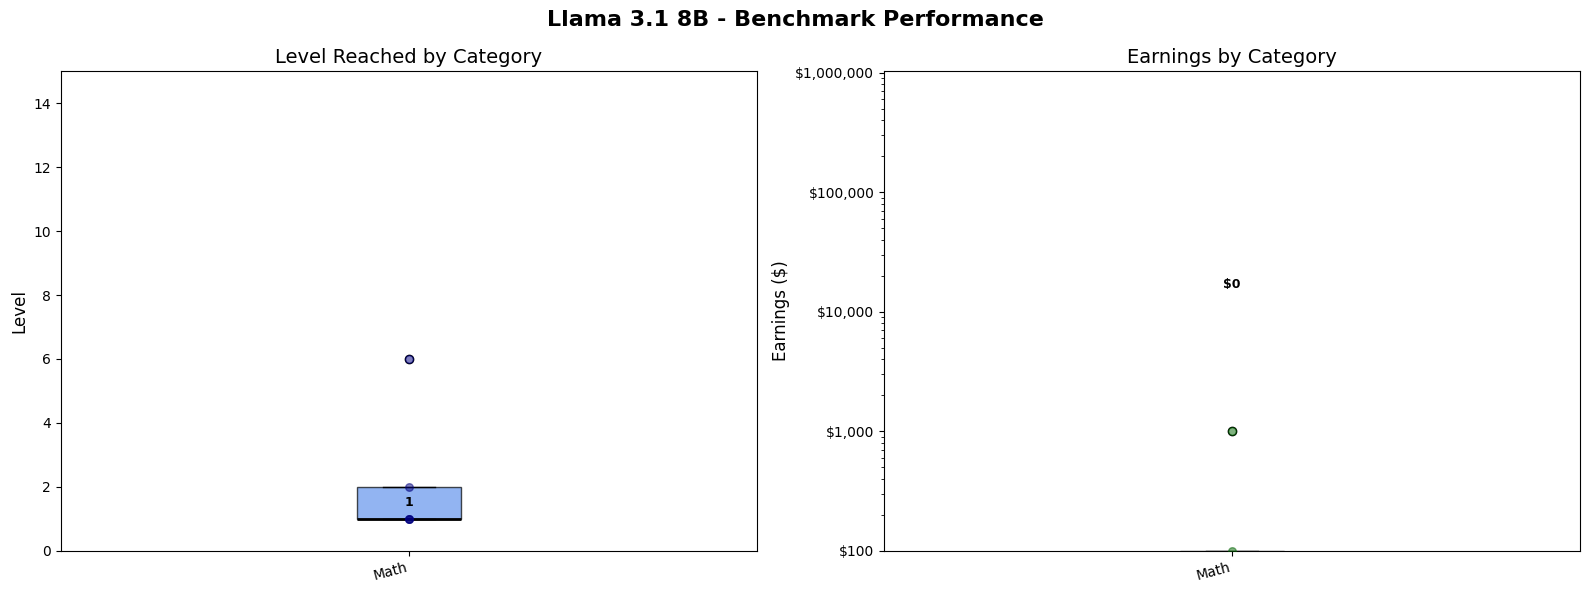

In [ ]:
plot_benchmark_results(experiment_data_agent_1)

#####vLLM Server configuration for Qwen Model (0.5B -> 14B) with Tool Use

######Qwen2.5 (1.5B) (quantization: Instruct-GPTQ-Int4) (with Tool Use)

In [ ]:
INIT_VLLM_CMD = f"""
nohup python -m vllm.entrypoints.openai.api_server \
    --model "Qwen/Qwen2.5-1.5B-Instruct-GPTQ-Int4" \
    --quantization gptq \
    --dtype float16 \
    --max-model-len 8192 \
    --gpu-memory-utilization 0.75 \
    --trust-remote-code \
    --enable-auto-tool-choice \
    --tool-call-parser hermes \
    --enforce-eager \
    --port 8000 > vllm.log 2>&1 &
"""
model_name="Qwen/Qwen2.5-1.5B-Instruct-GPTQ-Int4"

Test Results:

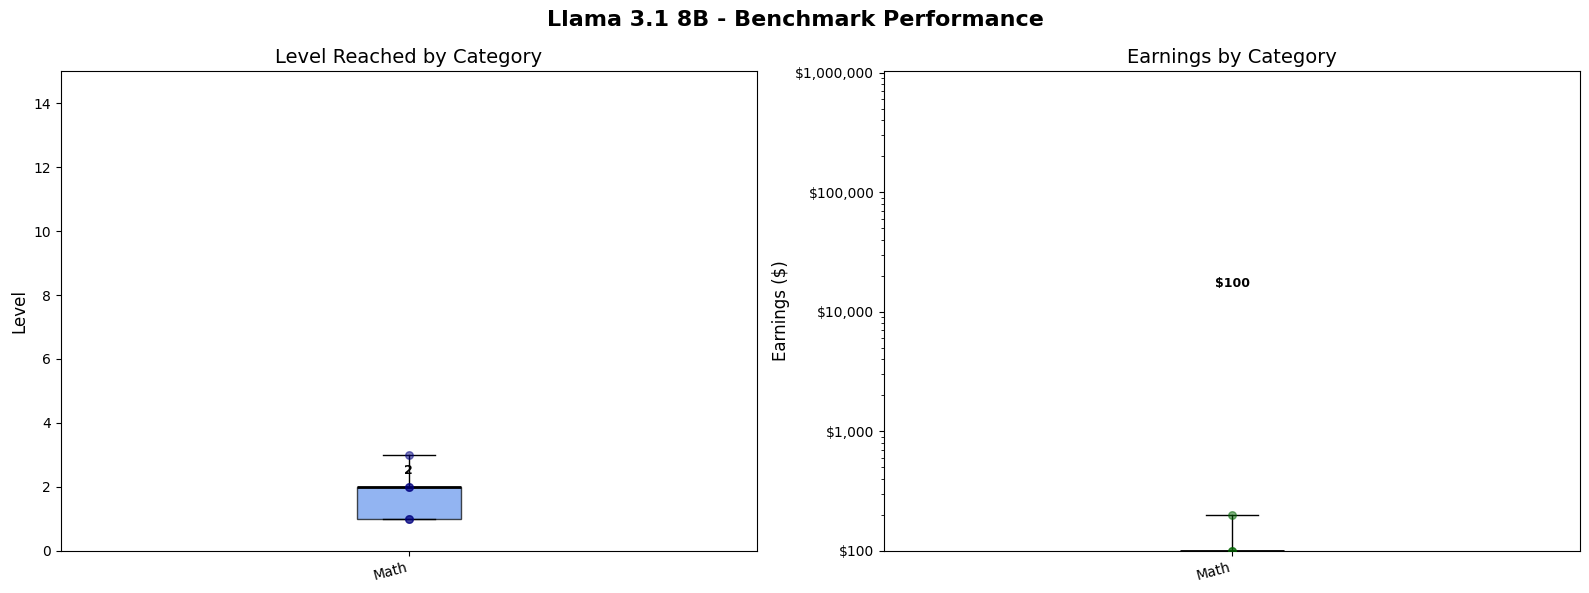

In [ ]:
plot_benchmark_results(experiment_data_agent_1)

######Qwen2.5 (7B) (quantization: Instruct-GPTQ-Int4) (with Tool Use)

In [ ]:
INIT_VLLM_CMD = f"""
nohup python -m vllm.entrypoints.openai.api_server \
    --model "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4" \
    --quantization gptq \
    --dtype float16 \
    --max-model-len 8192 \
    --gpu-memory-utilization 0.75 \
    --trust-remote-code \
    --enable-auto-tool-choice \
    --tool-call-parser hermes \
    --enforce-eager \
    --port 8000 > vllm.log 2>&1 &
"""
model_name="Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4"

Test Results:

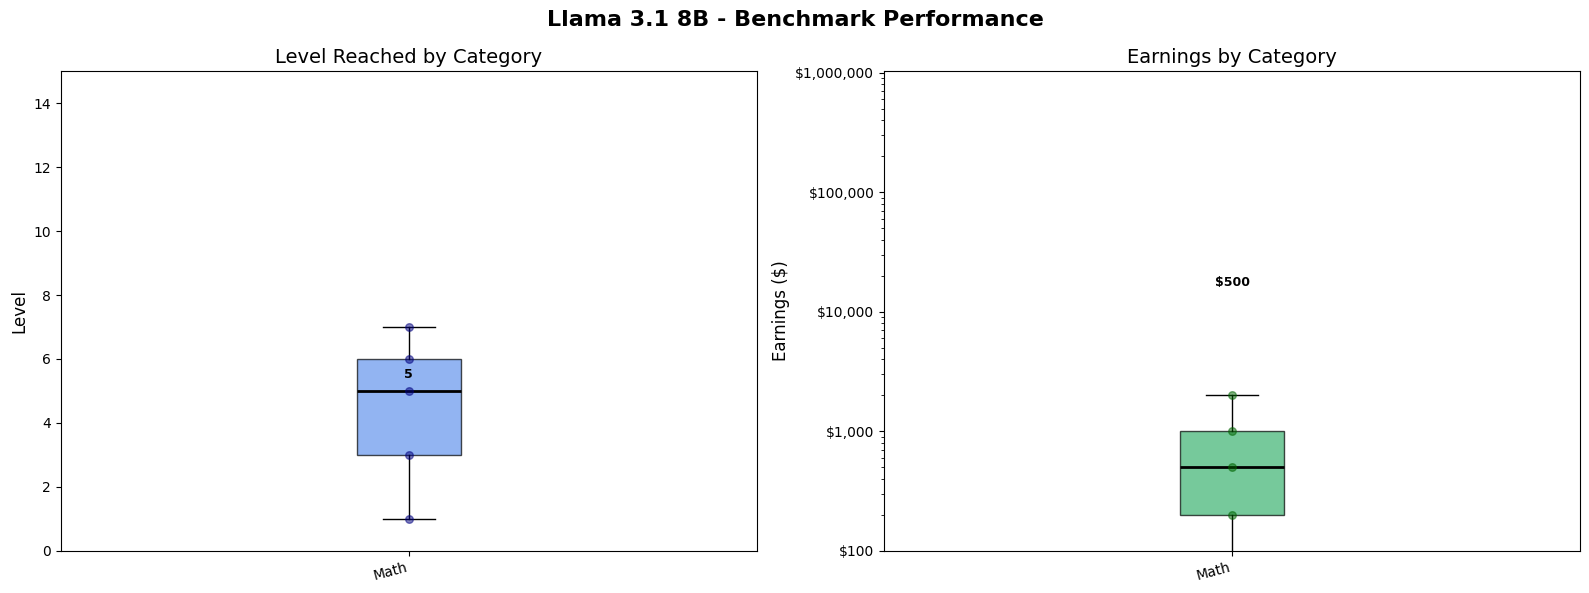

In [ ]:
plot_benchmark_results(experiment_data_agent_1)

#####Model Testing code without tool

In [ ]:
math_agent_sys_prompt_NO_tool = """You are an expert mathematical assistant. Solve multiple-choice questions step-by-step.
At the very end of your final response, you MUST write exactly: "FINAL ANSWER:[X]" (where [X] is [0], [1], [2], or [3]).
"""

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and the options. You must output ONLY the integer ID (0, 1, 2, or 3) of the correct option. Do not write any explanations, just the number."
NUM_GAMES = 5

math_agent_config = MathAgentConfig(
    system_prompt = math_agent_sys_prompt_NO_tool,
    max_tokens = 4096,
    temperature = 0.1,
    is_cot = True,
    max_agent_turns = 0
)

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = True,
    is_rag = True,
    is_agent = True
)

experiment_data_agent_1= run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=True,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config= math_agent_config
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Math (ID: 3) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 3) ---
Q: The maximum value of the function f (x) = xe^{–x} is

  [0] 1
  [1] -1
  [2] 1/e
  [3] e

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to specialist: MATH CALCULATOR TOOL
QUIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
0
 [System] Agent chose option: [2] (Time: 13.50s)

 [System] Reasoning: [To find the maximum value of the function \(f(x) = xe^{-x}\), we need to take its derivative and set it to zero to find the critical points.

First, let's rewrite the function as \(f(x) = xe^{-x}\).

Using the product rule, where if \(u = x\) and \(v = e^{-x}\), then \(u' = 1\) and \(v' = -e^{-x}\):

\[f'(x) = u'v + uv' = 1 \cdot e^{-x} + x \cdot (-e^{-x}) = e^{-x} - xe^{-x} = e^{-x}(1 - x)\]

Setting the derivative to zero:

\[e^{-x}(1 - x) = 0\]

Since \(e^{-x} \neq 0\) for any real number \(x\), we have:

\[1 - x = 0 \implies x 

#####Model Testing code with tool

In [ ]:
math_agent_sys_prompt_with_tool = """You are an expert mathematical assistant. Solve multiple-choice questions step-by-step.
Use the python_repl_tool to write and execute scripts to solve complex deterministic math computations.
At the very end of your final response, you MUST write exactly: "FINAL ANSWER:[X]" (where [X] is [0], [1], [2], or [3]).
"""

MODE = "text" # text/speech
SYS_PROMPT = "You are an expert trivia player. Read the question and the options. You must output ONLY the integer ID (0, 1, 2, or 3) of the correct option. Do not write any explanations, just the number."

NUM_GAMES = 5

math_agent_config = MathAgentConfig(
    system_prompt = math_agent_sys_prompt_with_tool,
    max_agent_turns = 20,
    max_tokens = 4096,
    temperature = 0.1,
    is_cot = True,
)

llama_config = LlamaConfig(
    sys_prompt = SYS_PROMPT,
    max_tokens = 300,
    is_cot = True,
    is_rag = True,
    is_agent = True
)

experiment_data_agent_1= run_benchmark(
    game_client=game_client,
    mode=MODE,
    num_games=NUM_GAMES,
    use_few_shot=True,
    examples_db=EXAMPLES_DB,
    llama_config = llama_config,
    math_agent_config= math_agent_config
)


 STARTING BENCHMARK (5 GAMES per topic)


 --- TESTING CATEGORY: Math (ID: 3) --- 
 --- Starting Game 1/5 ---

--- Level 1 (Categoria: 3) ---
Q: What interval consists of all $u$ such that neither $2u$ nor $-20u$ is in the interval $(-\infty,-1)$ ?

  [0] [-\frac{1}{2}, -\frac{1}{20}]
  [1] [-1,1]
  [2] [-\frac{1}{2}, 0]
  [3] [0,2]

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to specialist: MATH CALCULATOR TOOL
QUIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
20
 [System] Agent chose option: [0] (Time: 8.39s)

 [System] Reasoning: [To determine the interval for \( u \) where neither \( 2u \) nor \( -20u \) falls into the interval \((- \infty, -1)\), we need to analyze the conditions under which these expressions do not fall into the specified range.

1. For \( 2u \):
   - If \( 2u \) is in the interval \((- \infty, -1)\), then \( 2u < -1 \). Solving for \( u \), we get \( u < -\frac{1}{2} \).

2. For \( -20u \):
   - If \( -20u \) is in the interval \((- \inft

[The Math Agent is using the REPL Python interpreter]:
print('False, True')

 [System] Agent chose option: [3] (Time: 6.93s)

 [System] Reasoning: [Final Answer: [3]]

 WRONG ANSWER or TIMEOUT! Game Over!
 Final earnings: $500.00

=== Game Summary ===
Reached Level: 5
Total Earnings: $500.00
 --- Starting Game 2/5 ---

--- Level 1 (Categoria: 3) ---
Q: In the group G = {2, 4, 6, 8) under multiplication modulo 10, the identity element is

  [0] 8
  [1] 6
  [2] 2
  [3] 4

[System] Routing the question to the specialized agent...
  -> [Router] Assigned to specialist: MATH CALCULATOR TOOL
QUIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII
20
 [System] Agent chose option: [1] (Time: 10.96s)

 [System] Reasoning: [To determine the identity element in the group \(G = \{2, 4, 6, 8\}\) under multiplication modulo 10, we need to check which of these elements, when multiplied by any other element in the set, yields that same element back.

An identity element \(e\) in a group satisfies the property that for eve

#####Conclusion Math ReAct Agent test:
We can notice a big improvement in the peformance of the model:
* By increasing the dimension of the model
* By providing them the calculator (Python REPL interpreter) tool.

Looking at the output provided by the models the small models seem to have problems interacting with the tool, while the bigger ones are more capable.

I hypothesize that the reason for this difference is caused by the overhead required by the ReAct framework and the Pytho REPL tool. While readin official Alibaba documentation about qwen the reasearcher pointed out that because interacting with an external tool demands strict syntactic formatting and step-by-step thinking, smaller models lack some of the reasoning capacity to perform tool invocation, often leading to formatting errors or hallucinated code.

On the other hand, larger models are better at tackling complex reasoning loop effectively.

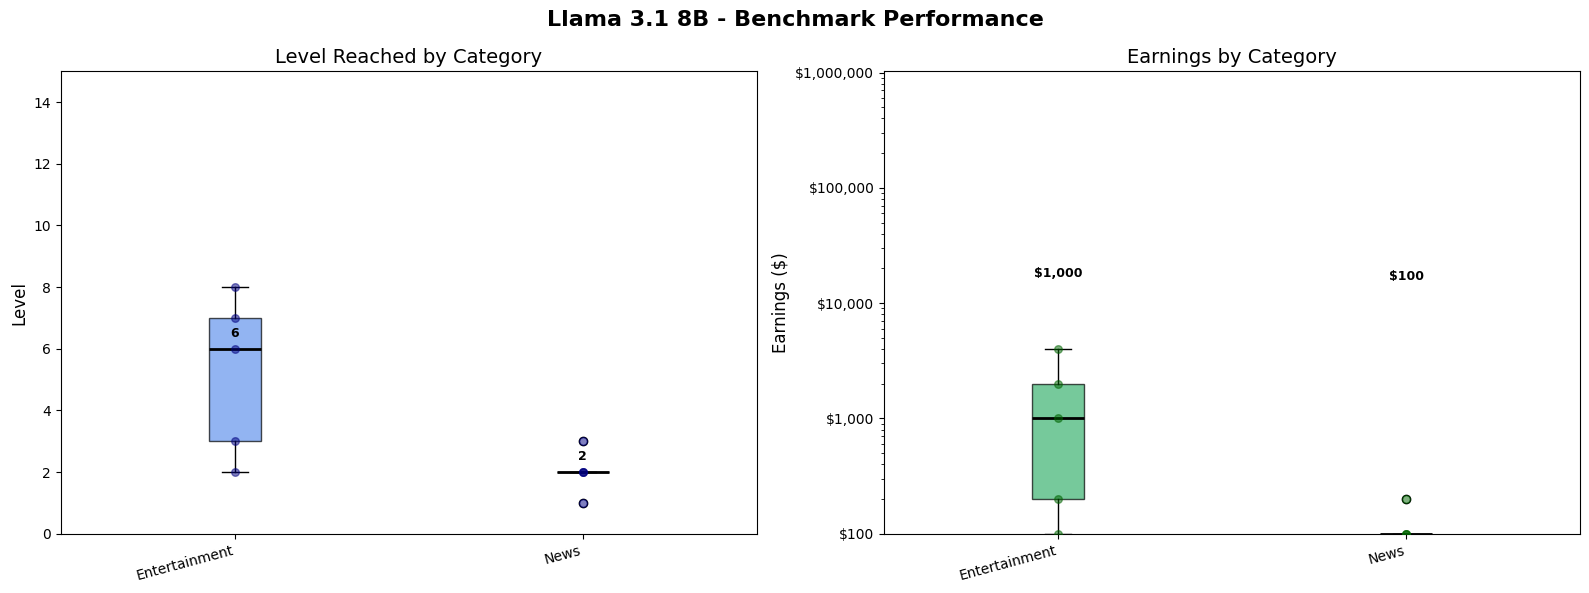

In [ ]:
plot_benchmark_results(experiment_data_agent_1)

## Speech Experiments

In [ ]:
# EXAMPLE:

SYS_PROMPT = "You are an expert trivia player. Read the question and the options. You must output ONLY the integer ID (0, 1, 2, or 3) of the correct option. Do not write any explanations, just the number."

# experiment parameters
MAX_TOKENS = 300
IS_COT = True
IS_RAG= False
IS_AGENT = False
USE_FEW_SHOT = False
NUM_GAMES = 3
MODE = None

#execute benchmark that run for every competition NUM_GAMES and pick the median result (to avoid suddenth dead)
experiment_data_speech = run_benchmark(
    game_client=game_client,
    mode="speech",
    num_games=NUM_GAMES,
    use_few_shot=True,
    llama_config = llama_config,
    math_agent_config= math_agent_config,
    examples_db=EXAMPLES_DB,
)


TypeError: run_benchmark() got an unexpected keyword argument 'client'

In [ ]:
plot_benchmark_results(experiment_data_speech)

###Results

### Comprehensive Experimentation Log: STT Reasoning Pipeline

#### 1. The "Acoustic Barrier"

* The Problem:** Whisper was hallucinating based on background noise and silence, treating all audio as speech.
* Action: Discovered the "Hallucination Loop."
* Key Fix: Set `condition_on_previous_text=False`, `temperature=0`, and `beam_size=5`.

#### 2. The Math Translation

* The Problem: The pipeline was producing literal transcripts for maths question (e.g., "fifteen thousand") instead of machine-readable notation (e.g., "15,000").
* Action: Developed `clean_text` (Regex-based filtering) and `normalize_math` (Symbolic mapping).
* Key Fix: Built a pattern-based sanitizer for phonetic math terms (`plus`, `minus`, `sigma`).

#### 3. The "Signal-to-Noise" Crisis

* The Problem: Encountered "gibberish" inputs (e.g., "throbbing heart," "wage winner") that Whisper attempted to transcribe as English sentences.
* Action: Tried `difflib.get_close_matches` to force inputs into valid options.
* Technical Insight: `get_close_matches` is ineffective when the underlying signal is pure noise. It lacks the semantic intelligence to differentiate between "a bad math attempt" and "background room noise."
* Misspelling correction libraries did not work as good as expected


#### 4. The "Latency & Architecture" Pivot

* The Problem: The 30-second budget makes secondary LLM calls risky; the current "Naive" regex approach is failing to filter semantic noise.
* Action: Transitioned from "trying to fix every transcript" to "detecting noise."
* Key Fix: Implemented `ffmpeg` (pre-processing) to standardize acoustic input and identified the need for a Semantic Gatekeeper (Small LLM Filter).


Accuracy Analysis Summary

The accuracy analysis focused on Word Error Rate (WER) and Character Error Rate (CER) to evaluate the model's transcription performance. The Ground Truth was obtained by manually listening to audios on small audio set. And then compared with transcriptions.
Key observations include:

Overall Distribution: Histograms showed the general distribution of WER and CER, indicating how frequently certain error rates occurred across all audio items. A significant portion of the data had very low (or zero) error rates, but there were also instances of higher errors.

Item Type Comparison: Bar plots comparing average WER and CER between questions and options revealed whether the model performed differently on the longer question audios versus the shorter option audios.

Competition ID Comparison: Grouped bar charts illustrated the average WER and CER for each competition_id, allowing us to identify if the model's accuracy varied significantly across different game categories or levels.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load the collected ground truth data from the JSON file
output_filename = "ground_truth_dataset.json"
with open(output_filename, "r") as f:
    ground_truth_data = json.load(f)

# Convert the data to a pandas DataFrame for easier analysis
df_ground_truth = pd.DataFrame(ground_truth_data)

# Display the first few rows of the DataFrame
print("Ground Truth DataFrame Head:")
display(df_ground_truth.head())


In [ ]:
!pip install jiwer

In [ ]:
import jiwer

def calculate_error_rate(reference, hypothesis, error_func):
    """
    Calculates an error rate (WER or CER) between a reference and hypothesis.
    Handles empty strings: if one is empty and the other is not, returns 1.0 (max error);
    if both are empty, returns 0.0 (no error).
    """
    if not isinstance(reference, str) or not isinstance(hypothesis, str):
        # Ensure inputs are strings, otherwise treat as max error for safety
        return 1.0

    reference_stripped = reference.strip()
    hypothesis_stripped = hypothesis.strip()

    if not reference_stripped and not hypothesis_stripped:
        return 0.0 # Both empty or whitespace only, considered a match
    if not reference_stripped or not hypothesis_stripped:
        return 1.0 # One is empty/whitespace, other is not, considered max error

    # jiwer expects lists of strings for reference and hypothesis
    return error_func([reference_stripped], [hypothesis_stripped])

print("WER/CER calculation functions defined.")

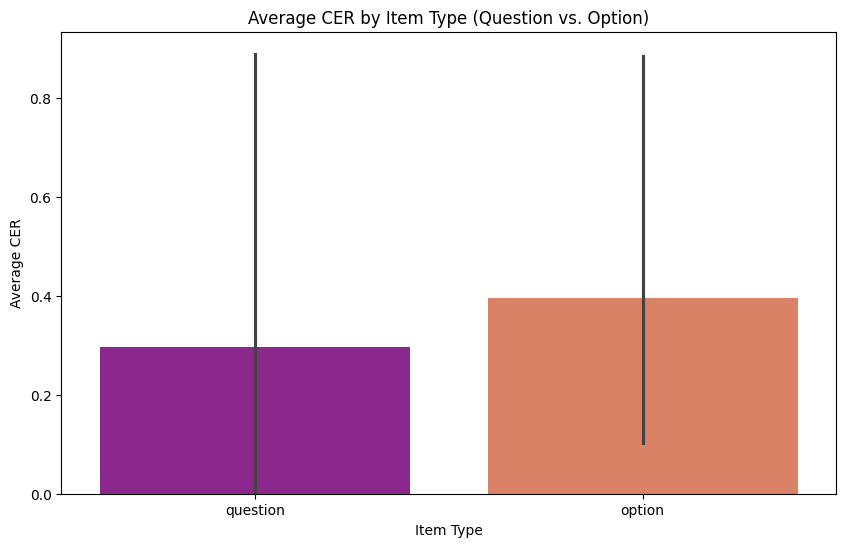

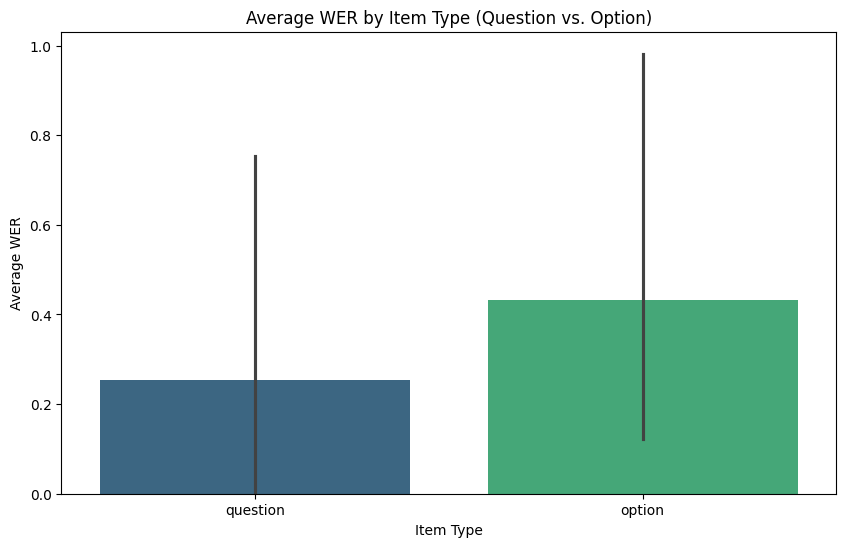

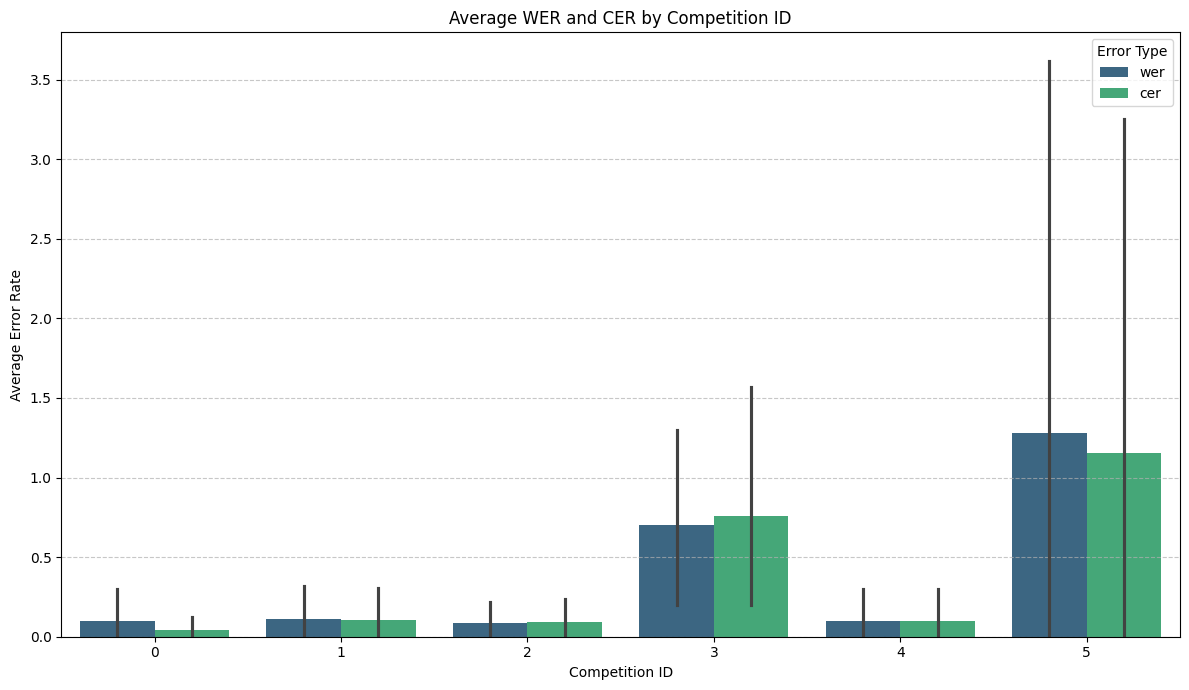

Latency Analysis Summary

The latency analysis investigated the transcription speed of the Speech-to-Text model under various configurations, comparing Whisper models (medium vs. small) and decoding strategies (greedy, beam_5, temperature_0.7).

Key takeaways from the visualizations and statistical summary are:

Model Size: As expected, the small Whisper model consistently demonstrated significantly lower mean transcription latency compared to the medium model across all decoding strategies. This confirms that smaller models are faster.

Decoding Strategy:
Greedy Decoding: Generally provided the fastest transcription times for both models, indicating its efficiency when a quick, straightforward transcription is preferred.

Beam_5 Decoding: Showed higher latency than greedy search, especially for the medium model. This is typical, as beam search explores multiple paths to find a more optimal transcription, requiring more computation.

Temperature_0.7 Sampling: For the medium model, this strategy sometimes yielded lower mean latency than beam_5, but often with higher variability (larger standard deviation and max values), suggesting less predictable performance. For the small model, greedy was still the fastest, with temperature_0.7 being slightly slower than beam_5 on average but with a very high max value.

Variability: The standard deviation and maximum latency values, particularly for the medium model and temperature_0.7 on the small model, indicate that some audio files or transcription conditions can lead to significantly longer processing times. This suggests the presence of outliers or specific audio characteristics that challenge the model or strategy.



In [ ]:
import time
import whisper
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-using the audio files collected for ground truth
# Let's pick a sample of these for latency testing to avoid excessive run time
latency_test_audio_dir = "ground_truth_audio"
all_audio_files = [os.path.join(latency_test_audio_dir, f) for f in os.listdir(latency_test_audio_dir) if f.endswith('.wav')]

# Select a subset of audio files for latency testing (e.g., 20 files)
np.random.seed(42) # for reproducibility
sample_audio_files = np.random.choice(all_audio_files, size=min(20, len(all_audio_files)), replace=False)
print(f"Selected {len(sample_audio_files)} audio files for latency testing.")

def measure_transcription_latency(model, audio_path, **kwargs):
    """
    Measures the time taken to transcribe an audio file using the given Whisper model.
    """
    start_time = time.time()
    _ = model.transcribe(audio_path, **kwargs)
    end_time = time.time()
    return end_time - start_time

print("Latency measurement function defined.")

In [ ]:
# Load different Whisper models
print("Loading Whisper models...")
model_medium = whisper.load_model("medium")
print("Loaded whisper-medium.")
model_small = whisper.load_model("small")
print("Loaded whisper-small.")

# Store models in a dictionary for easy iteration
whisper_models = {
    "medium": model_medium,
    "small": model_small
}

print("Whisper models (medium and small) loaded.")

In [ ]:
latency_results = []

# Define test configurations
configurations = [
    {"model_name": "medium", "temperature": 0, "beam_size": 1, "strategy": "greedy"},
    {"model_name": "medium", "temperature": 0, "beam_size": 5, "strategy": "beam_5"},
    {"model_name": "medium", "temperature": 0.7, "beam_size": None, "strategy": "temperature_0.7"}, # When beam_size is None, temperature is used for sampling
    {"model_name": "small", "temperature": 0, "beam_size": 1, "strategy": "greedy"},
    {"model_name": "small", "temperature": 0, "beam_size": 5, "strategy": "beam_5"},
    {"model_name": "small", "temperature": 0.7, "beam_size": None, "strategy": "temperature_0.7"}
]

print("Starting latency measurements for various configurations...")
for audio_file in sample_audio_files:
    for config in configurations:
        model = whisper_models[config["model_name"]]

        transcribe_kwargs = {}
        if config["temperature"] is not None:
            transcribe_kwargs["temperature"] = config["temperature"]
        if config["beam_size"] is not None:
            transcribe_kwargs["beam_size"] = config["beam_size"]

        latency = measure_transcription_latency(model, audio_file, **transcribe_kwargs)

        latency_results.append({
            "model": config["model_name"],
            "strategy": config["strategy"],
            "temperature": config["temperature"],
            "beam_size": config["beam_size"],
            "audio_file": audio_file,
            "latency_seconds": latency
        })
        print(f"  Measured latency for {config['model_name']} ({config['strategy']}) on {os.path.basename(audio_file)}: {latency:.2f}s")

df_latency = pd.DataFrame(latency_results)
print("Latency measurements complete. Displaying first 5 rows of results:")
display(df_latency.head())


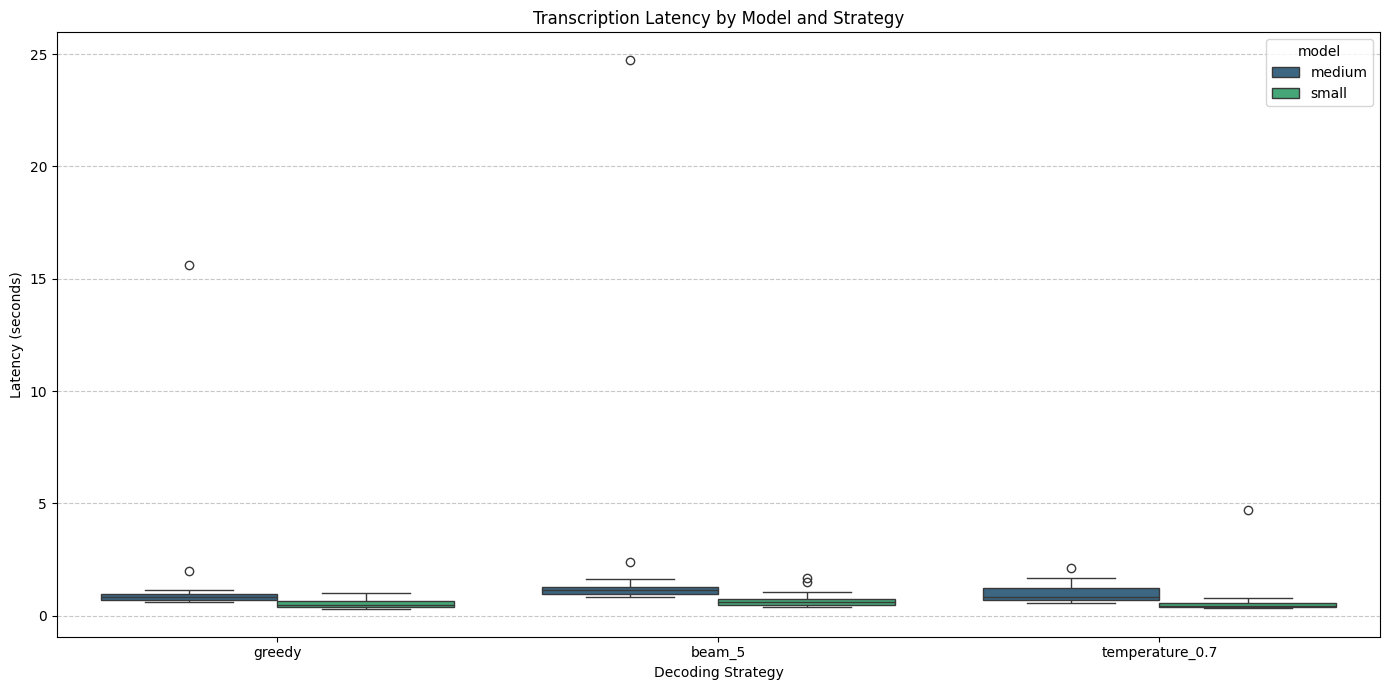

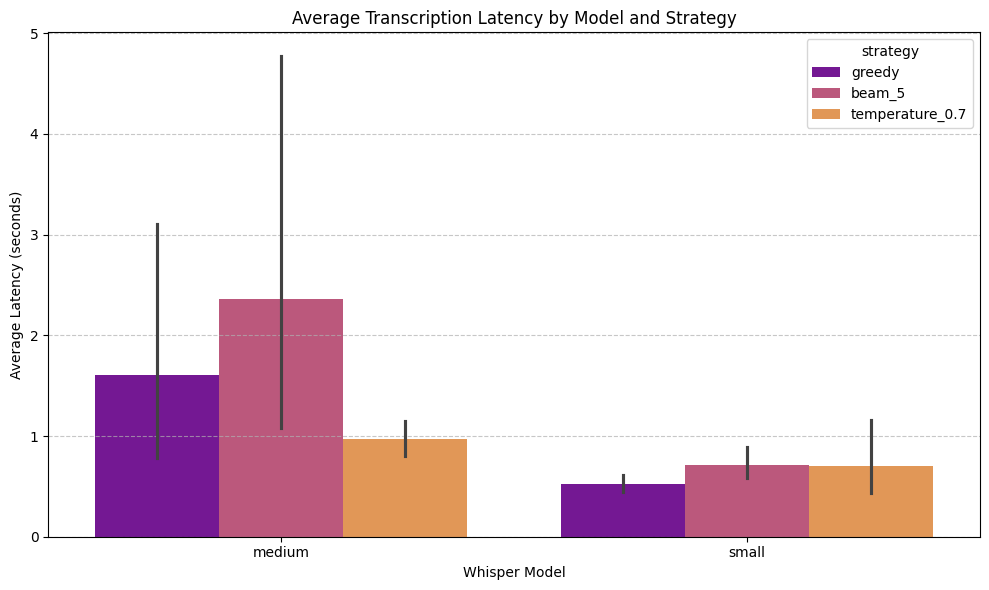